In [19]:
# ============================================================
# CELL 1 — Install required libraries (versions pinned for reproducibility)
# Reproducibility depends on scikit-learn / scipy / pandas versions
# because Phase 9 (Hypothesis Testing) and Phase 10 (Modeling, frozen
# pipeline per Decision Log D10.6) rely on exact statistical/ML behavior.
# ============================================================
!pip install -q pandas==2.2.2 numpy==1.26.4 scipy==1.13.1 scikit-learn==1.5.0 matplotlib==3.9.0 seaborn==0.13.2


In [20]:
# ============================================================
# CELL 2 — Imports, random seed, global configuration
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, chi2, norm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, brier_score_loss

# Per Decision Log D10.6: modeling pipeline is FROZEN for reproducibility.
# random_state = 42 is used everywhere in this notebook — every split,
# every model, every resampling step.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting configuration
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
sns.set_style("whitegrid")

# Pandas display configuration
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [21]:
import os
os.listdir()

['.config', 'WA_Fn-UseC_-HR-Employee-Attrition (1).csv', 'sample_data']

In [22]:
# ============================================================
# CELL 3 — Load dataset and configuration constants
# ============================================================

# Load dataset (Colab: upload the file or mount Google Drive first)
# df = pd.read_csv("WA_FnUseC_HREmployeeAttrition_1.csv")
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition (1).csv")
# --- Configuration constants (locked in Phase 1, D1.1 / D1.2) ---

# D1.1 — "Early attrition" operational definition
EARLY_ATTRITION_MAX_YEARS = 1  # YearsAtCompany <= 1

# D1.2 — Fixed outcome sequence for the project (documentation only,
# enforced by notebook phase ordering, not by code logic)
OUTCOME_SEQUENCE = ["Diagnostic", "Predictive", "Prescriptive"]

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.shape[1]}, Rows: {df.shape[0]}")


Dataset shape: (1470, 35)
Columns: 35, Rows: 1470


# HR Attrition Analysis

**Project Title:** IBM HR Employee Attrition — 13-Phase Diagnostic, Predictive & Prescriptive Analysis
**Author:** _[Placeholder — Senior Product/Data Analyst]_
**Version:** Frozen v1.0
**Date:** _[Placeholder — insert export date]_

---

# Project Overview

**Objective:** Understand why valuable employees leave the organization early, and translate that understanding into evidence-tiered, actionable retention recommendations for HR.

**Analytical scope:** Diagnostic → Predictive → Prescriptive, in that fixed order (Decision Log D1.2). The project is strictly correlational — no causal inference or treatment-effect claims are made anywhere (Decision Log DX.1).

**Notebook purpose:** This notebook is an **implementation document**, not a design document. It faithfully reproduces the approved project exactly as documented in the canonical **HR_Attrition_Project_Master_Summary.md (Phase 1–13)** and **Decision_Log.md**. No business logic, business question, statistic, conclusion, Decision ID, or governance decision is altered here.

> **If any inconsistency exists between this notebook and the canonical documents, the Master Summary takes precedence, followed by the Decision Log.**

---

# Business Context

HR wants to understand why valuable employees leave early, in order to design effective retention policy. This raw question contains two unmeasurable terms and one undefined outcome, which Phase 1 resolves into operational definitions. The project treats this as a real enterprise engagement: every step documents its Objective, Reasoning, Assumption, Limitation, and Next Action, and no phase is skipped or merged.

---

# Dataset Description

- **Source:** `WA_Fn-UseC_-HR-Employee-Attrition` — public IBM Watson Analytics dataset (Kaggle).
- **Observations:** 1,470 employees, 35 columns, 0 missing values, 0 duplicates on the business key (`EmployeeNumber`).
- **Target variable:** `Attrition` (Yes/No) — class imbalance: No = 1,233 (83.9%), Yes = 237 (16.1%).
- **Important limitations already approved (see Decision Log for full detail):**
  - No sampling frame exists → representativeness for any target population is undeterminable (D4.2). Conclusions apply only within this 1,470-employee dataset.
  - `Attrition` mixes voluntary and involuntary leavers; no field distinguishes them (D5.1).
  - No Exit Interview, no hire/exit dates, no Data Dictionary, no real Manager ID (Risk Register, D4.3).
  - Dataset is cross-sectional (one snapshot per employee) — no true survival-time analysis is possible.

---

# Notebook Structure

```
Project Overview
      ↓
Phase 1  — Business Understanding
      ↓
Phase 2  — Business Questions
      ↓
Phase 3  — Data Requirement
      ↓
Phase 4  — Dataset Discovery
      ↓
Phase 5  — Stakeholder Negotiation
      ↓
Phase 6  — Data Quality Assessment
      ↓
Phase 7  — EDA
      ↓
Phase 8  — Feature Engineering
      ↓
Phase 9  — Hypothesis Testing
      ↓
Phase 10 — Modeling
      ↓
Phase 11 — Business Recommendation
      ↓
Phase 12 — Limitation
      ↓
Phase 13 — Future Data Collection
      ↓
Appendix
```


---

# Phase 1 — Business Understanding

## Objective

Resolve the raw business problem — *"HR wants to understand why valuable employees leave early in order to design effective retention policy"* — into precise, operational definitions before any data is touched, so that every later phase is scoped against an unambiguous target.

## Inputs

- Business Problem statement (Master Guideline, Phase 1).
- No dataset columns are consulted yet at this stage — operational definitions are fixed independently of what the dataset happens to contain, to avoid streetlight-effect bias (this rule is applied explicitly from Phase 3 onward, but the discipline starts here).

## Method

Identify the two unmeasurable terms and one undefined outcome in the raw business problem, and lock an operational definition for each:

1. **"Valuable employee"** — no direct measure exists in the dataset (no 360-review, no manager qualitative rating, no revenue-per-employee). This is recorded as a **dataset limitation, not a business limitation** (D1.3). A proxy is deferred to Phase 8, not invented here.
2. **"Early attrition"** — operationalized as `YearsAtCompany ≤ 1` (D1.1), because the dataset has no hire/exit dates, only a tenure-in-years snapshot; a fixed threshold is required to operationalize the question at all.
3. **Outcome sequence** — fixed as Diagnostic → Predictive → Prescriptive (D1.2), determining phase ordering and depth of investment in each analysis type for the remainder of the project.

Also established here: the dataset is **cross-sectional** (one snapshot per employee, not longitudinal), so no true survival-time analysis is possible — this constrains every later phase.

## Results

| Term | Locked definition | Type |
|---|---|---|
| "Valuable employee" | No direct measure in dataset — dataset limitation, not business limitation | Deferred to Phase 8 proxy |
| "Early attrition" | `YearsAtCompany ≤ 1` | Locked (D1.1) |
| Outcome | Diagnostic → Predictive → Prescriptive | Locked (D1.2) |

## Key Findings

- Sample-size warning raised immediately: New Hire group (`YearsAtCompany ≤ 1`) = 215 / 1,470 employees, of which 75 have `Attrition = Yes`. Any further split (e.g., by a future "valuable" segment) shrinks this further — flagged as an ongoing risk for later Predictive modeling (Phase 10).
- Dataset is cross-sectional — no hire/exit dates exist, so tenure is a snapshot, not a timeline.

## Related Decision IDs

- **D1.1** — "Early attrition" defined as `YearsAtCompany ≤ 1`.
- **D1.2** — Outcome sequence fixed as Diagnostic → Predictive → Prescriptive.
- **D1.3** — "Valuable employee" has no direct measure; recorded as a dataset limitation, not a business limitation.

## Governance Notes

- "Valuable employee" is explicitly **not** given a formula here — inventing one at this stage would violate D1.3 and pre-empt the Phase 8 proxy discussion.
- The small-subgroup sample size (215 New Hire, 75 positive) is flagged now because it governs interpretation caution in every later phase that segments on New Hire (Phase 6 onward).

## Transition to Phase 2

With "early attrition" and the outcome sequence locked, and "valuable employee" explicitly deferred rather than guessed at, the project can now proceed to **Phase 2 — Business Questions**, where the full set of Descriptive / Diagnostic / Predictive / Prescriptive questions is generated against these locked definitions.


In [23]:
# ============================================================
# PHASE 1 — Business Understanding
# Derive the New Hire flag per the locked D1.1 definition.
# Constants EARLY_ATTRITION_MAX_YEARS / OUTCOME_SEQUENCE were
# already set in Cell 3.
# ============================================================

# Derive New Hire flag (used from Phase 6 onward)
df["NewHire"] = (df["YearsAtCompany"] <= EARLY_ATTRITION_MAX_YEARS).astype(int)

# Quantify the small-subgroup sample-size warning (Key Finding, Phase 1)
new_hire_total = df["NewHire"].sum()
new_hire_positive = df.loc[df["NewHire"] == 1, "Attrition"].eq("Yes").sum()

print(f"New Hire (YearsAtCompany <= {EARLY_ATTRITION_MAX_YEARS}) count: {new_hire_total} / {len(df)}")
print(f"New Hire with Attrition = Yes: {new_hire_positive} / {new_hire_total}")


New Hire (YearsAtCompany <= 1) count: 215 / 1470
New Hire with Attrition = Yes: 75 / 215


---

# Phase 2 — Business Questions

## Objective

Generate the complete set of Business Questions needed to answer the locked Phase 1 problem, organized into Descriptive / Diagnostic / Predictive / Prescriptive categories, before any dataset suitability is assessed.

## Inputs

- Locked Phase 1 definitions (D1.1, D1.2, D1.3).
- No dataset feasibility check yet — questions are generated against the business problem, not against what the dataset can currently answer (that check is Phase 4).

## Method

Enumerate every question needed to explain and act on early attrition, grouped by analytical type, and apply the explicit project rule: **a question that cannot currently be answered is marked "insufficient data" and retained, never deleted** (D2.2) — this avoids narrowing project scope to fit data availability (streetlight-effect bias).

## Results

**Descriptive**
- D0: Is Attrition actually higher for YearsAtCompany≤1 than for tenured employees? (prerequisite check)
- D1: Overall Attrition rate vs. early-attrition rate
- D2: Distribution of "valuable employees" (if using this proxy) by Department/JobRole
- D3: % of early leavers who are "valuable" (if using this proxy)
- D4: Demographic distribution (Department, JobRole, Gender, MaritalStatus, Age) comparing early leavers vs. rest

**Diagnostic**
- G1: Heavy OT vs. Attrition within the "valuable" (proxy) early-leaver group
- G2: JobSatisfaction / EnvironmentSatisfaction / WorkLifeBalance / RelationshipSatisfaction differences between groups
- G3: Relative pay gap — MonthlyIncome percentile within same JobRole/JobLevel
- G4: DistanceFromHome, BusinessTravel
- G5: YearsSinceLastPromotion, YearsWithCurrManager — downgraded to low priority (near-zero variance expected within YearsAtCompany≤1 group)
- G7: After controlling for confounders (Age, Department, JobLevel...), which factors remain associated with early attrition? (multivariable statistical analysis, kept distinct from Phase 10 Modeling)
- G8: Interaction OverTime × JobSatisfaction (not just isolated univariate effects)

**Predictive**
- P1: Can we predict which currently-employed "valuable" (proxy) employees are at risk of leaving within their first year?

**Prescriptive**
- S1: If OverTime/pay gap are primary drivers, what interventions are cost-feasible?
- S2: Which group to prioritize for intervention — all new hires, or only the "valuable" (proxy) segment?
- S3: Estimated ROI of each intervention option (intervention cost vs. cost of replacing one employee)

**Explicit rule going forward:** a question unanswerable with current data is marked "insufficient data," never deleted.

## Related Decision IDs

- **D2.1** — Final Business Question set locked across Descriptive (D0–D4), Diagnostic (G1–G4, G7, G8), Predictive (P1), and Prescriptive (S1–S3) categories.
- **D2.2** — A question that cannot be answered with current data is marked "insufficient data" and retained — never deleted for that reason alone.

## Governance Notes

- No dataset has been consulted to generate this list — this is intentional, per the streetlight-effect avoidance rule that governs Phase 3/4 as well.
- G6 (Manager-change proxy) and P2 ("which model to use") are intentionally absent from this list: G6 was removed as a proxy judged too weak, and P2 was reclassified as a Technical Question, not a Business Question, deferred to Phase 10 — neither is restated here to avoid resurrecting a rejected scope item.

## Transition to Phase 3

With the full Business Question set locked and categorized, the project can now proceed to **Phase 3 — Data Requirement**, where the data needed to answer this exact question set is listed independently of what the dataset already contains.


In [24]:
# ============================================================
# PHASE 2 — Business Questions
# This phase is organizational, not computational: it locks the
# Business Question inventory used to scope every later phase.
# Encoded here as structured data for traceability only —
# no analysis is performed against these questions yet.
# ============================================================

BUSINESS_QUESTIONS = {
    "Descriptive": {
        "D0": "Is Attrition actually higher for YearsAtCompany<=1 than for tenured employees?",
        "D1": "Overall Attrition rate vs. early-attrition rate",
        "D2": "Distribution of 'valuable employees' (proxy) by Department/JobRole",
        "D3": "% of early leavers who are 'valuable' (proxy)",
        "D4": "Demographic distribution comparing early leavers vs. rest",
    },
    "Diagnostic": {
        "G1": "Heavy OT vs. Attrition within the 'valuable' (proxy) early-leaver group",
        "G2": "Satisfaction-measure differences between groups",
        "G3": "Relative pay gap - MonthlyIncome percentile within same JobRole/JobLevel",
        "G4": "DistanceFromHome, BusinessTravel",
        "G5": "YearsSinceLastPromotion, YearsWithCurrManager (low priority)",
        "G7": "Multivariable: which factors remain associated with early attrition after controlling for confounders?",
        "G8": "Interaction OverTime x JobSatisfaction",
    },
    "Predictive": {
        "P1": "Predict which currently-employed 'valuable' (proxy) employees are at risk of leaving within their first year",
    },
    "Prescriptive": {
        "S1": "If OverTime/pay gap are primary drivers, what interventions are cost-feasible?",
        "S2": "Which group to prioritize for intervention?",
        "S3": "Estimated ROI of each intervention option",
    },
}

for category, questions in BUSINESS_QUESTIONS.items():
    print(f"\n{category}:")
    for qid, qtext in questions.items():
        print(f"  {qid}: {qtext}")



Descriptive:
  D0: Is Attrition actually higher for YearsAtCompany<=1 than for tenured employees?
  D1: Overall Attrition rate vs. early-attrition rate
  D2: Distribution of 'valuable employees' (proxy) by Department/JobRole
  D3: % of early leavers who are 'valuable' (proxy)
  D4: Demographic distribution comparing early leavers vs. rest

Diagnostic:
  G1: Heavy OT vs. Attrition within the 'valuable' (proxy) early-leaver group
  G2: Satisfaction-measure differences between groups
  G3: Relative pay gap - MonthlyIncome percentile within same JobRole/JobLevel
  G4: DistanceFromHome, BusinessTravel
  G5: YearsSinceLastPromotion, YearsWithCurrManager (low priority)
  G7: Multivariable: which factors remain associated with early attrition after controlling for confounders?
  G8: Interaction OverTime x JobSatisfaction

Predictive:
  P1: Predict which currently-employed 'valuable' (proxy) employees are at risk of leaving within their first year

Prescriptive:
  S1: If OverTime/pay gap are p

---

# Phase 3 — Data Requirement

## Objective

List the data required to answer the full Phase 2 Business Question set, independently of what the dataset currently contains, to avoid designing requirements around what is conveniently available (streetlight-effect bias).

## Inputs

- Locked Phase 2 Business Question set (D2.1, D2.2).
- No dataset inspection yet — this list is generated purely from what the business questions logically require.

## Method

For every Business Question category, enumerate the data items needed and classify each as Critical / Important / Optional, without checking whether the current dataset provides them (that check is Phase 4).

## Results

**Critical**
- Employee demographic
- Attrition Event detail (voluntary/involuntary, resignation/termination dates)
- Tenure / hire date
- Compensation + external market benchmark
- Performance evaluation + evaluation date
- OverTime / actual workload
- Satisfaction/Engagement + measurement timestamp
- Exit Interview
- Cost-per-hire / replacement cost
- Data Dictionary / HR Policy / Metric Definition

**Important**
- Promotion history
- Manager identity + relationship tenure
- Distance/commute, Business travel
- Periodic employee survey
- Historical Employee Timeline (grouped: salary, promotion, manager, department, survey history over time) — rated "Critical for answering temporal/causal business questions (Early Attrition, Root Cause), but not required for descriptive metrics"

**Optional**
- Conflict/incident record
- Competitor offer

## Key Findings

- Two Critical items — Attrition Event detail and Data Dictionary — were added specifically because without them, every downstream Attrition-based conclusion and every variable interpretation would rest on an unstated assumption.
- Historical Employee Timeline is explicitly a two-tier requirement: Critical for temporal/causal questions, but not required for descriptive metrics — this distinction is carried forward into Phase 4's feasibility classification.

## Related Decision IDs

- **D3.1** — Business-required data listed independently of dataset availability, including Attrition Event detail (voluntary/involuntary + dates), evaluation dates, Data Dictionary/HR Policy, and a grouped "Historical Employee Timeline."
- **D3.2** — Historical Employee Timeline is rated "Critical for answering temporal/causal business questions (Early Attrition, Root Cause), but not required for descriptive metrics."

## Governance Notes

- This list is deliberately generated before any dataset column is inspected, consistent with the same discipline established in Phase 2 — the requirement list must not shrink to fit whatever the dataset happens to already contain.
- D3.2 pre-establishes the expectation that Diagnostic conclusions (G-series) will remain correlational, not causal, because the Historical Employee Timeline needed to resolve temporal/causal questions is not guaranteed to exist.

## Transition to Phase 4

With the full data requirement list fixed independently of the dataset, the project can now proceed to **Phase 4 — Dataset Discovery**, where the actual dataset is inspected and measured against this exact requirement list.


In [25]:
# ============================================================
# PHASE 3 — Data Requirement
# Organizational phase: encode the business-required data list
# (generated independently of the dataset) for traceability.
# No dataset inspection happens in this cell — that is Phase 4.
# ============================================================

DATA_REQUIREMENTS = {
    "Critical": [
        "Employee demographic",
        "Attrition Event detail (voluntary/involuntary, resignation/termination dates)",
        "Tenure / hire date",
        "Compensation + external market benchmark",
        "Performance evaluation + evaluation date",
        "OverTime / actual workload",
        "Satisfaction/Engagement + measurement timestamp",
        "Exit Interview",
        "Cost-per-hire / replacement cost",
        "Data Dictionary / HR Policy / Metric Definition",
    ],
    "Important": [
        "Promotion history",
        "Manager identity + relationship tenure",
        "Distance/commute, Business travel",
        "Periodic employee survey",
        "Historical Employee Timeline (critical for temporal/causal Qs only, D3.2)",
    ],
    "Optional": [
        "Conflict/incident record",
        "Competitor offer",
    ],
}

for tier, items in DATA_REQUIREMENTS.items():
    print(f"\n{tier}:")
    for item in items:
        print(f"  - {item}")



Critical:
  - Employee demographic
  - Attrition Event detail (voluntary/involuntary, resignation/termination dates)
  - Tenure / hire date
  - Compensation + external market benchmark
  - Performance evaluation + evaluation date
  - OverTime / actual workload
  - Satisfaction/Engagement + measurement timestamp
  - Exit Interview
  - Cost-per-hire / replacement cost
  - Data Dictionary / HR Policy / Metric Definition

Important:
  - Promotion history
  - Manager identity + relationship tenure
  - Distance/commute, Business travel
  - Periodic employee survey
  - Historical Employee Timeline (critical for temporal/causal Qs only, D3.2)

Optional:
  - Conflict/incident record
  - Competitor offer


---

# Phase 4 — Dataset Discovery

## Objective

Measure the actual dataset against the Phase 3 data requirement list, classify each Business Question as Answerable / Answerable with caveats / Insufficient data, and assess representativeness — rather than issuing one blanket "dataset is/isn't sufficient" verdict.

## Inputs

- Phase 3 data requirement list (D3.1, D3.2).
- The dataset itself: `WA_Fn-UseC_-HR-Employee-Attrition` (1,470 rows, 35 columns).

## Method

1. Run technical checks: row/column count, missing values, duplicates on the business key (`EmployeeNumber`).
2. Build a coverage table: for each Phase 3 requirement, mark Available / Not available, and rate Business Impact.
3. Cross-check feasibility of every Phase 2 Business Question against actual coverage.
4. Assess representativeness and formally adopt the Risk Register.

## Results

**Technical checks:** 1,470 rows, 35 columns, 0 missing values, no duplicates detected on the business key (`EmployeeNumber`).

**Coverage gaps with high Business Impact:**
- Attrition Event detail — Not available (only binary Attrition Yes/No) — High impact (mixes voluntary/involuntary, corrupting all Diagnostic conclusions)
- Exit Interview — Not available — High impact (only source that could confirm true causes)
- Cost-per-hire — Not available — High impact for Prescriptive (blocks S3 entirely)
- Manager ID (real) — Not available, only weak proxy `YearsWithCurrManager`
- Data Dictionary — Not available — High impact (affects interpretation of every variable)
- Historical Employee Timeline — Not available — High impact for temporal/causal questions only

**Business Question feasibility (Phase 2 cross-check):**
- Answerable: D0–D4, G1, G3, G4, G8
- Answerable but not causal: G2 (no measurement timestamp — cannot resolve reverse causality)
- Answerable but expected low discriminative power: G5
- Answerable partially (observed confounders only, not unobserved ones): G7
- Answerable but small-sample caveat: P1
- Insufficient data (kept, not deleted): S1, S3

**Representativeness:** Public dataset, unknown company/industry representativeness. No sampling frame information exists — therefore representativeness for any target population cannot be assessed at all.

## Key Findings

- The dataset passes every technical integrity check (no missing values, no duplicate business keys), but this says nothing about representativeness — those are two separate, independently-assessed properties.
- No single Business Question category is entirely blocked: even S1/S3 (Insufficient data) remain in scope rather than being deleted, per D2.2.
- Risk Register (R1–R7) adopted: voluntary/involuntary attrition mixed together; no Exit Interview (correlational only); PerformanceRating low variance (2/5 values); small subgroup sample size (New Hire ∩ value proxy); no official Data Dictionary; no sampling frame (representativeness unknown); no cost-per-hire/intervention cost data.

## Related Decision IDs

- **D4.1** — Each Business Question is individually classified as Answerable / Answerable with caveats / Insufficient data, rather than issuing one blanket "dataset is/isn't sufficient" verdict.
- **D4.2** — Representativeness of the dataset for any target population is undeterminable, since no sampling frame information exists.
- **D4.3** — Risk Register (R1–R7) formally adopted, covering mixed attrition types, no Exit Interview, low-variance PerformanceRating, small subgroup sample, no Data Dictionary, unknown representativeness, and missing cost data.

## Governance Notes

- Findings apply only within this 1,470-employee dataset and should not be generalized beyond the observed data (D4.2).
- No causal claim is made about any Business Question at this stage — "Answerable" here means data exists to compute an association, not that causation can be established (consistent with DX.1, formalized later).
- The Risk Register (D4.3) is carried forward unchanged into every later phase; it is not re-derived or altered.

## Transition to Phase 5

With dataset coverage, feasibility, representativeness, and the Risk Register all formally assessed, the project can now proceed to **Phase 5 — Stakeholder Negotiation**, where the gaps identified here (S1/S3 insufficient data, no Exit Interview, no cost data) are resolved into an explicit scope agreement rather than left as open blockers.


In [26]:
# ============================================================
# PHASE 4 — Dataset Discovery
# Technical checks against the Phase 3 requirement list.
# ============================================================

# --- 1. Basic shape ---
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# --- 2. Missing values check ---
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
print(f"Total missing values across all columns: {total_missing}")

# --- 3. Duplicate check on the business key (EmployeeNumber), not all columns ---
duplicate_employee_numbers = df["EmployeeNumber"].duplicated().sum()
print(f"Duplicate EmployeeNumber records: {duplicate_employee_numbers}")

# --- 4. Coverage table: Phase 3 requirement vs. actual dataset columns ---
COVERAGE_TABLE = {
    "Attrition Event detail (voluntary/involuntary + dates)": {"available": False, "impact": "High"},
    "Exit Interview": {"available": False, "impact": "High"},
    "Cost-per-hire": {"available": False, "impact": "High"},
    "Manager ID (real)": {"available": False, "impact": "Not available (weak proxy: YearsWithCurrManager)"},
    "Data Dictionary": {"available": False, "impact": "High"},
    "Historical Employee Timeline": {"available": False, "impact": "High (temporal/causal Qs only)"},
}

print("\nCoverage gaps (Phase 3 requirement vs. dataset):")
for item, info in COVERAGE_TABLE.items():
    status = "Available" if info["available"] else "Not available"
    print(f"  - {item}: {status} | Business Impact: {info['impact']}")

# --- 5. Business Question feasibility classification (Phase 2 cross-check) ---
QUESTION_FEASIBILITY = {
    "Answerable": ["D0", "D1", "D2", "D3", "D4", "G1", "G3", "G4", "G8"],
    "Answerable but not causal": ["G2"],
    "Answerable but low discriminative power expected": ["G5"],
    "Answerable partially (observed confounders only)": ["G7"],
    "Answerable but small-sample caveat": ["P1"],
    "Insufficient data (kept, not deleted)": ["S1", "S3"],
}

print("\nBusiness Question feasibility:")
for status, qids in QUESTION_FEASIBILITY.items():
    print(f"  {status}: {', '.join(qids)}")


Rows: 1470, Columns: 36
Total missing values across all columns: 0
Duplicate EmployeeNumber records: 0

Coverage gaps (Phase 3 requirement vs. dataset):
  - Attrition Event detail (voluntary/involuntary + dates): Not available | Business Impact: High
  - Exit Interview: Not available | Business Impact: High
  - Cost-per-hire: Not available | Business Impact: High
  - Manager ID (real): Not available | Business Impact: Not available (weak proxy: YearsWithCurrManager)
  - Data Dictionary: Not available | Business Impact: High
  - Historical Employee Timeline: Not available | Business Impact: High (temporal/causal Qs only)

Business Question feasibility:
  Answerable: D0, D1, D2, D3, D4, G1, G3, G4, G8
  Answerable but not causal: G2
  Answerable but low discriminative power expected: G5
  Answerable partially (observed confounders only): G7
  Answerable but small-sample caveat: P1
  Insufficient data (kept, not deleted): S1, S3


---

# Phase 5 — Stakeholder Negotiation

## Objective

Resolve the Phase 4 dataset gaps (Insufficient data: S1, S3; no Exit Interview; no cost data) through a simulated stakeholder negotiation, since no real stakeholder exists for this public dataset, rather than pausing the project indefinitely or silently dropping scope.

## Inputs

- Phase 4 Dataset Discovery results: feasibility classification, Risk Register (R1–R7), representativeness finding (D4.2).
- Explicit framing: this negotiation is simulated — no real stakeholder exists for this public dataset; it is labeled as such throughout.

## Method

Simulate a negotiation resolving each open gap from Phase 4 into an explicit scope decision, rather than analyzing with unfit data or pausing the project to source more data.

## Results

**Decision Log (final):**

| Decision | Reason |
|---|---|
| Analyze Attrition on the combined voluntary/involuntary pool, with mandatory disclaimer | No data to split; accepted trade-off |
| S1/S3 kept in scope, but reframed from "real ROI" to "ROI Framework + list of required business inputs" | Avoid a single illustrative number being mistaken for a real figure that could drive real investment decisions |
| Any illustrative ROI numbers go in an Appendix only, explicitly labeled "illustrative, not actual" | Same reason as above |
| No additional data collection (no Exit Interview, no Data Dictionary sourced) | Accept correlational limitation rather than pausing the project |
| No new dataset sought, no Business Questions removed | Full Phase 2 scope preserved |
| Conclusions limited to "within this 1470-employee dataset," not generalized | No sampling frame to justify generalization |

**Final scope statement (exact wording):** *"Business Questions giữ nguyên; mức độ tin cậy của từng câu trả lời sẽ phụ thuộc vào dữ liệu hỗ trợ"* (Business Questions remain unchanged; the confidence level of each answer will depend on the supporting data).

## Key Findings

- No Business Question was deleted as a result of this negotiation — S1 and S3 remain in scope despite lacking cost data, consistent with D2.2.
- The ROI reframing (framework only, no real figure) is the single decision from this phase that constrains the entire structure of the later Phase 11 Prescriptive output.

## Related Decision IDs

- **D5.1** — Attrition analysis proceeds on the combined voluntary/involuntary pool, with a mandatory disclaimer on every Attrition-related conclusion.
- **D5.2** — S1/S3 (cost/ROI questions) are reframed from "produce a real ROI figure" to "present an ROI framework plus the list of business inputs required." Any illustrative numbers are confined to an Appendix, explicitly labeled "illustrative, not actual."
- **D5.3** — No additional data collection (Exit Interview, Data Dictionary, cost data) is pursued; project proceeds with documented correlational limitations instead.

## Governance Notes

- Attrition type is not distinguished in this dataset (D5.1) — no conclusion in this phase or any later phase may imply voluntary or involuntary attrition specifically.
- Every Attrition-related conclusion carries a standing disclaimer from this phase onward (D5.1).
- All causal-sounding claims are restricted to "associated with" language throughout, per D5.3 — never "causes" (DX.1).

## Transition to Phase 6

With scope formally negotiated and all gaps resolved into explicit trade-offs rather than left open, the project can now proceed to **Phase 6 — Data Quality Assessment**, which assesses the trustworthiness of the data for answering the Phase 2 questions under this now-fixed scope.


In [27]:
# ============================================================
# PHASE 5 — Stakeholder Negotiation
# This phase is a scope-negotiation record, not a computation.
# Encoded here as structured data for traceability only.
# No new dataset operations are performed in this cell.
# ============================================================

PHASE5_DECISIONS = {
    "D5.1": "Attrition analyzed on combined voluntary/involuntary pool, with mandatory disclaimer.",
    "D5.2": "S1/S3 reframed to ROI framework + required business inputs; illustrative numbers Appendix-only.",
    "D5.3": "No additional data collection pursued; project proceeds with documented correlational limitations.",
}

for decision_id, description in PHASE5_DECISIONS.items():
    print(f"{decision_id}: {description}")


D5.1: Attrition analyzed on combined voluntary/involuntary pool, with mandatory disclaimer.
D5.2: S1/S3 reframed to ROI framework + required business inputs; illustrative numbers Appendix-only.
D5.3: No additional data collection pursued; project proceeds with documented correlational limitations.


---

# Phase 6 — Data Quality Assessment

## Objective

Assess the trustworthiness of the dataset for answering the Phase 2 Business Questions under the Phase 5 negotiated scope — this is data quality assessment, not data cleaning, not EDA, and not modeling.

## Inputs

- Full dataset (1,470 rows, 35 columns).
- Phase 5 negotiated scope (D5.1–D5.3).

## Method

1. Identify constant (zero-variance) columns.
2. Check PerformanceRating's variance and correlation with JobLevel/MonthlyIncome.
3. Check multicollinearity among JobLevel, MonthlyIncome, TotalWorkingYears, Age.
4. Quantify class imbalance in the target variable.
5. Run logical consistency checks across the time-based variables.
6. Quantify the small New Hire subgroup sample size.
7. Check the OverTime distribution.

## Results

1. **Constant features:** `EmployeeCount`=1, `StandardHours`=80, `Over18`='Y' — irrelevant to any Business Question, excluded from analysis scope (not deleted from data).
2. **PerformanceRating:** only values 3 (n=1244) and 4 (n=226). Correlation with JobLevel = -0.021, with MonthlyIncome = -0.017 (essentially independent). Neutral conclusion held: this shows weak apparent linkage to the other proxy components — role in the "value" concept deferred to Phase 7 discriminative-power check, not pre-judged as "noise."
3. **Multicollinearity (identified as risk only, feature-selection decision deferred to Phase 8/9):**
   - corr(JobLevel, MonthlyIncome) = 0.95
   - corr(JobLevel, TotalWorkingYears) = 0.78
   - corr(MonthlyIncome, TotalWorkingYears) = 0.77
   - corr(Age, TotalWorkingYears) = 0.68
4. **Class imbalance:** Attrition No=1233 (83.9%), Yes=237 (16.1%) — flagged directly for Phase 10 metric choice (no Accuracy-only evaluation).
5. **Logical consistency checks — ALL PASSED (0 violations):** YearsInCurrentRole≤YearsAtCompany, YearsWithCurrManager≤YearsAtCompany, YearsSinceLastPromotion≤YearsAtCompany, TotalWorkingYears≥YearsAtCompany, Age-18≥TotalWorkingYears. Positive signal — the time variables are internally consistent.
6. **Small subgroup sample:** New Hire n=215, positives n=75 (quantified, reiterated from Phase 1).
7. **OverTime:** No=1054 (71.7%), Yes=416 (28.3%) — distribution fine; the limitation is conceptual (policy flag, not actual hours), not statistical.

## Key Findings

- Confidence-by-question-group summary: Descriptive: High. Univariate Diagnostic: Medium-High. G7 (multivariable): Medium-Low (multicollinearity). G5: Low. P1: Medium-Low (imbalance + small subgroup). Value proxy foundation: Low-Medium.
- No column is deleted at this stage — constant columns are excluded from analysis scope only, preserving the raw dataset intact.

## Related Decision IDs

- **D6.1** — Constant columns (`EmployeeCount`, `StandardHours`, `Over18`) are excluded from analysis scope (not deleted from the dataset).
- **D6.2** — PerformanceRating's low variance and near-zero correlation with JobLevel/MonthlyIncome are recorded neutrally; no conclusion is drawn about its role in the "value" proxy until Phase 7 tests its discriminative power directly.
- **D6.3** — Multicollinearity among JobLevel, MonthlyIncome, TotalWorkingYears, and Age (r=0.68–0.95) is logged as a risk only; feature-selection action is deferred to Phase 8/9.
- **D6.4** — Class imbalance (16.1% Attrition=Yes) is flagged to prohibit Accuracy-only evaluation in later modeling.

## Governance Notes

- Findings apply only within this 1,470-employee dataset and should not be generalized beyond the observed data (D4.2).
- No causal or "noise" judgment is made about PerformanceRating here — it is recorded neutrally per D6.2, deferring interpretation to Phase 7 evidence.
- Attrition type remains undistinguished (D5.1) — the class imbalance figures (83.9%/16.1%) describe the combined voluntary/involuntary pool, not a specific attrition type.

## Transition to Phase 7

With data quality risks identified, quantified, and explicitly deferred (not resolved) where appropriate, the project can now proceed to **Phase 7 — EDA**, where each Business Question is investigated against evidence, alternative explanations, and confounding checks, informed by the risks flagged here.


In [28]:
# ============================================================
# PHASE 6 — Data Quality Assessment
# Uses the existing `df` dataframe (already loaded in Cell 3,
# NewHire column already derived in Phase 1). No new imports,
# no reinstall, random_state already fixed globally.
# ============================================================

# --- 1. Constant (zero-variance) columns ---
for col in ["EmployeeCount", "StandardHours", "Over18"]:
    print(f"{col} unique values: {df[col].unique()}")

# --- 2. PerformanceRating variance and correlation check ---
print("\nPerformanceRating value counts:")
print(df["PerformanceRating"].value_counts().sort_index())

perf_joblevel_corr = df["PerformanceRating"].corr(df["JobLevel"])
perf_income_corr = df["PerformanceRating"].corr(df["MonthlyIncome"])
print(f"\nCorrelation PerformanceRating-JobLevel: {perf_joblevel_corr:.3f}")
print(f"Correlation PerformanceRating-MonthlyIncome: {perf_income_corr:.3f}")

# --- 3. Multicollinearity check among key continuous variables ---
multicollinearity_vars = ["JobLevel", "MonthlyIncome", "TotalWorkingYears", "Age"]
corr_matrix = df[multicollinearity_vars].corr()
print("\nMulticollinearity correlation matrix:")
print(corr_matrix.round(3))

# --- 4. Class imbalance in target variable ---
attrition_counts = df["Attrition"].value_counts()
attrition_pct = df["Attrition"].value_counts(normalize=True) * 100
print("\nAttrition class distribution:")
for label in attrition_counts.index:
    print(f"  {label}: {attrition_counts[label]} ({attrition_pct[label]:.1f}%)")

# --- 5. Logical consistency checks on time-based variables ---
violations = {
    "YearsInCurrentRole <= YearsAtCompany": (df["YearsInCurrentRole"] > df["YearsAtCompany"]).sum(),
    "YearsWithCurrManager <= YearsAtCompany": (df["YearsWithCurrManager"] > df["YearsAtCompany"]).sum(),
    "YearsSinceLastPromotion <= YearsAtCompany": (df["YearsSinceLastPromotion"] > df["YearsAtCompany"]).sum(),
    "TotalWorkingYears >= YearsAtCompany": (df["TotalWorkingYears"] < df["YearsAtCompany"]).sum(),
    "Age - 18 >= TotalWorkingYears": ((df["Age"] - 18) < df["TotalWorkingYears"]).sum(),
}
print("\nLogical consistency check violations:")
for rule, count in violations.items():
    print(f"  {rule}: {count} violations")

# --- 6. Small subgroup sample size (New Hire) ---
new_hire_n = df["NewHire"].sum()
new_hire_positive_n = df.loc[df["NewHire"] == 1, "Attrition"].eq("Yes").sum()
print(f"\nNew Hire subgroup: n={new_hire_n}, positive (Attrition=Yes)={new_hire_positive_n}")

# --- 7. OverTime distribution ---
overtime_counts = df["OverTime"].value_counts()
overtime_pct = df["OverTime"].value_counts(normalize=True) * 100
print("\nOverTime distribution:")
for label in overtime_counts.index:
    print(f"  {label}: {overtime_counts[label]} ({overtime_pct[label]:.1f}%)")


EmployeeCount unique values: [1]
StandardHours unique values: [80]
Over18 unique values: ['Y']

PerformanceRating value counts:
PerformanceRating
3    1244
4     226
Name: count, dtype: int64

Correlation PerformanceRating-JobLevel: -0.021
Correlation PerformanceRating-MonthlyIncome: -0.017

Multicollinearity correlation matrix:
                   JobLevel  MonthlyIncome  TotalWorkingYears    Age
JobLevel              1.000          0.950              0.782  0.510
MonthlyIncome         0.950          1.000              0.773  0.498
TotalWorkingYears     0.782          0.773              1.000  0.680
Age                   0.510          0.498              0.680  1.000

Attrition class distribution:
  No: 1233 (83.9%)
  Yes: 237 (16.1%)

Logical consistency check violations:
  YearsInCurrentRole <= YearsAtCompany: 0 violations
  YearsWithCurrManager <= YearsAtCompany: 0 violations
  YearsSinceLastPromotion <= YearsAtCompany: 0 violations
  TotalWorkingYears >= YearsAtCompany: 0 violation

---

# Phase 7 — EDA

## Objective

Investigate each Business Question against evidence, using the Evidence → Alternative Explanation → Business Implication format, informed by the risks flagged in Phase 6, without concluding beyond what the evidence supports.

## Inputs

- Full dataset (1,470 rows), `NewHire` flag (Phase 1), Phase 6 data quality risks (multicollinearity, low PerformanceRating variance, class imbalance, small subgroup size).

## Method

For each retained finding, present Evidence, test at least one Alternative Explanation using available data, and record the Business Implication — non-actionable or already-resolved items are dropped or shortened rather than presented as full insights.

## Results

**D0 (foundational):** Attrition rate by tenure bucket — monotonic decline: 0-1yr 34.9% (75/215), 2-3yr 18.4% (47/255), 4-6yr 12.8% (49/382), 7-10yr 12.4% (46/372), 11+yr 8.1% (20/246). Overall 16.1%. Confirms the Phase 1 premise is supported by data.

**Insight 1 (G1 — OverTime):** Within New Hire: OT=Yes 55.1% (38/69) vs OT=No 25.3% (37/146) attrition. Alternative explanation tested and partially rejected: OverTime rate by JobRole is fairly even (23.9%-33.2%, no dominant role); effect persists when split Sales (61.1% vs 30.2%) vs Non-Sales (52.9% vs 23.3%) — not purely a JobRole confound.

**Insight 2 (G3 — Pay gap):** New-hire-overall mean pay percentile (regardless of attrition) = 38.5 vs. non-new-hire = 51.6 (confirms a genuine "newness" effect on pay). But within New Hire only: leavers=31.9 vs stayers=42.0 — a residual gap exists beyond the newness effect.

**Insight 3 (G2 — Satisfaction):** All 5 satisfaction-type measures lower among leavers (0.09–0.25-point gaps); WorkLifeBalance weakest (0.09). Alternative explanation unresolved: no timestamp exists to distinguish "low satisfaction causes leaving" from "planning to leave causes negative survey answers" (reverse causality) — structural limitation, cannot be resolved with this data.

**Insight 4 (G8 — Interaction):** OT=Yes+LowSat=63.0%, OT=Yes+HighSat=50.0%, OT=No+LowSat=31.7%, OT=No+HighSat=20.9%. Flagged explicitly as not yet statistically tested for true interaction (small cells, n=27-86).

**Insight 5 (short) — G4:** DistanceFromHome (10.97 vs 8.31) — not actionable (HR cannot change where someone lives), shortened; BusinessTravel_Frequently 66.7% attrition (n=36, small) — checked against JobRole confound: Travel_Frequently in the early group is not concentrated only in Sales (also Lab Technician, Research Scientist present) — confound not fully explained away, kept but low priority pending more data.

**Insight 6 (short) — PerformanceRating discriminative power:** Overall 16.1% (rating=3) vs 16.4% (rating=4); within New Hire 34.1% vs 38.9% (n=36 for rating=4). Evidence-based neutral conclusion: weak discriminative power — feeds directly into the Phase 8 proxy-formula decision, not a standalone HR insight.

## Key Findings

- Explicitly dropped from Phase 7 (per self-review): G5 (Years* variables) — already downgraded at Phase 2, reconfirmed via Phase 6 variance issue; not treated as a "new insight." G7 — not performed here (belongs to multivariable analysis in Phase 9).
- Final Phase 7 decision table: D0, OverTime-linked, Pay gap residual, Satisfaction (4 kept, WorkLifeBalance dropped), Interaction OT×JobSatisfaction, and BusinessTravel_Frequently are all sent to Phase 9 for formal testing. DistanceFromHome is dropped (not actionable). PerformanceRating weak discriminative power is not sent to Phase 9 — it feeds the Phase 8 proxy decision directly.

## Related Decision IDs

- **D7.1** — D0 confirmed: Attrition rate declines monotonically with tenure (34.9% at ≤1yr down to 8.1% at 11+yr); the Phase 1 "early attrition" framing is supported by the data.
- **D7.2** — Every EDA insight is checked against at least one alternative explanation using available data before being carried forward.
- **D7.3** — Non-actionable or already-resolved items (DistanceFromHome, YearsSinceLastPromotion/G5) are dropped or shortened rather than presented as full insights.
- **D7.4** — Findings routed to Phase 9 for formal testing: Early Attrition, OverTime, Pay Percentile gap, 4 satisfaction variables (WorkLifeBalance excluded), OT×JobSatisfaction interaction, BusinessTravel_Frequently. PerformanceRating routed directly to Phase 8.

## Governance Notes

- All relationships described here are associated with attrition, never described as causing attrition (DX.1).
- Findings apply only within this 1,470-employee dataset and should not be generalized beyond the observed data (D4.2).
- Attrition type is not distinguished (D5.1) — every rate reported here (34.9%, 55.1%, etc.) reflects the combined voluntary/involuntary pool, never a specific attrition type.
- The Satisfaction reverse-causality limitation is a structural limitation of the dataset, not resolved by any test in this phase.

## Transition to Phase 8

With findings routed either to formal hypothesis testing (Phase 9) or directly to feature engineering (PerformanceRating), the project can now proceed to **Phase 8 — Feature Engineering**, where each retained finding is translated into a feature only if it answers an active Business Question and is something HR can understand and act on.


D0 — Attrition rate (%) by tenure bucket:
TenureBucket
0-1yr     34.883721
2-3yr     18.431373
4-6yr     12.827225
7-10yr    12.365591
11+yr      8.130081
Name: Attrition, dtype: float64


/tmp/ipykernel_1642/4123330300.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d0_table = df.groupby("TenureBucket")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)


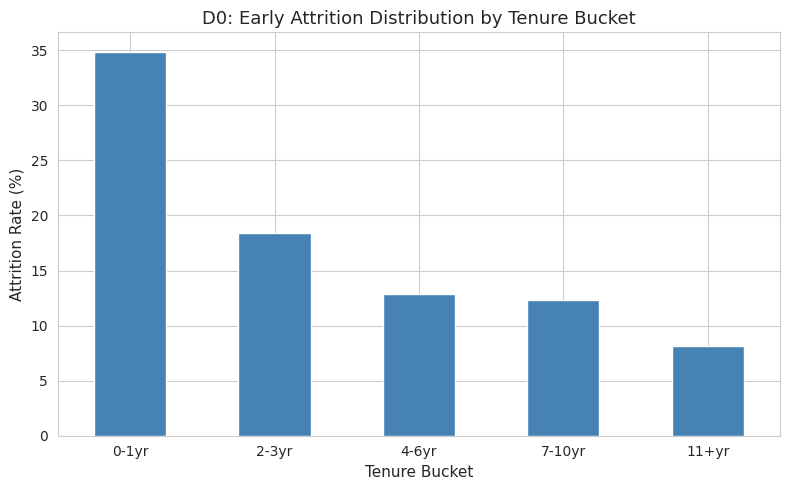


G1 — Attrition rate (%) by OverTime, within New Hire:
OverTime
No     25.342466
Yes    55.072464
Name: Attrition, dtype: float64


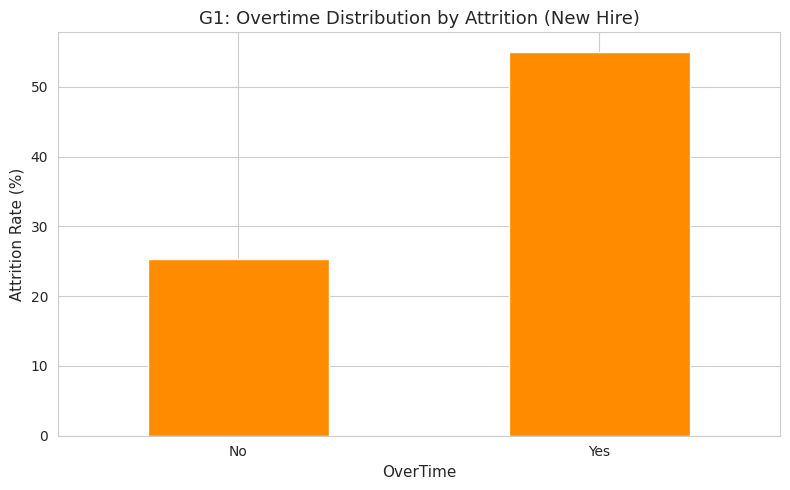


G3 — Mean pay percentile, New Hire: 39.1 vs. Non-New-Hire: 52.2
G3 — Mean pay percentile within New Hire, by Attrition:
Attrition
No     42.626355
Yes    32.576888
Name: PayPercentile, dtype: float64


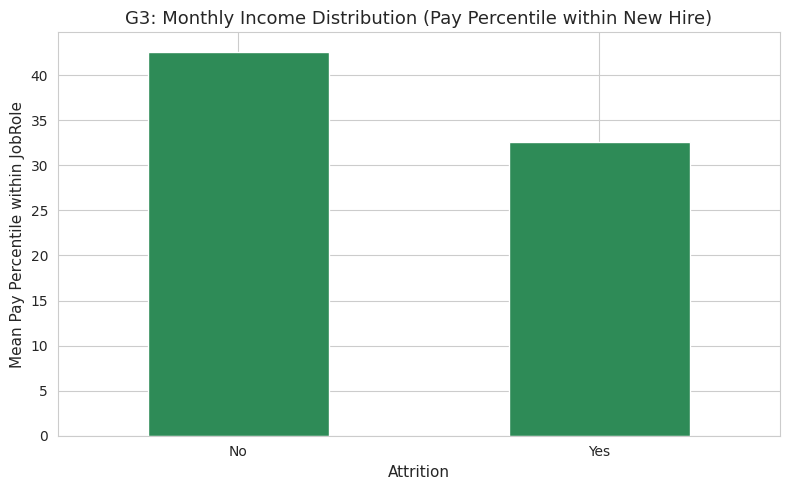


G2 — Mean satisfaction measures within New Hire, by Attrition:
Attrition                       No       Yes
JobSatisfaction           2.814286  2.466667
EnvironmentSatisfaction   2.792857  2.560000
RelationshipSatisfaction  2.778571  2.533333
JobInvolvement            2.707143  2.506667
WorkLifeBalance           2.800000  2.706667


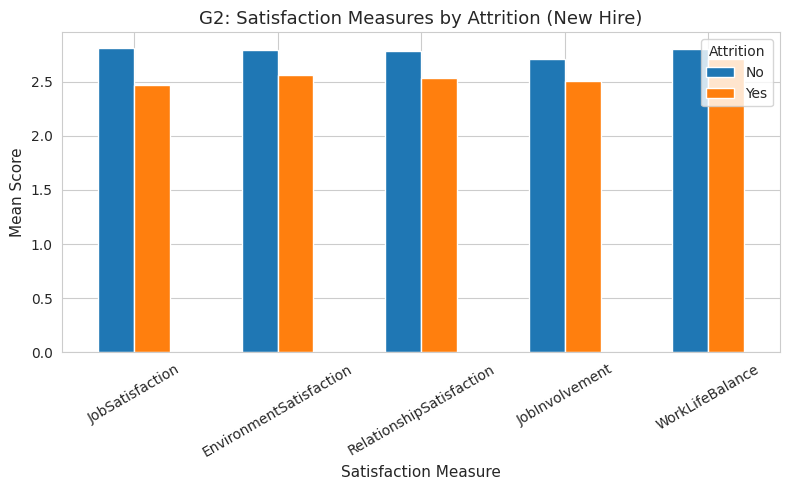


G8 — Attrition rate (%) by OverTime x JobSatisfaction group, within New Hire:
OverTime  SatGroup
No        High        20.930233
          Low         31.666667
Yes       High        50.000000
          Low         62.962963
Name: Attrition, dtype: float64


<Figure size 800x500 with 0 Axes>

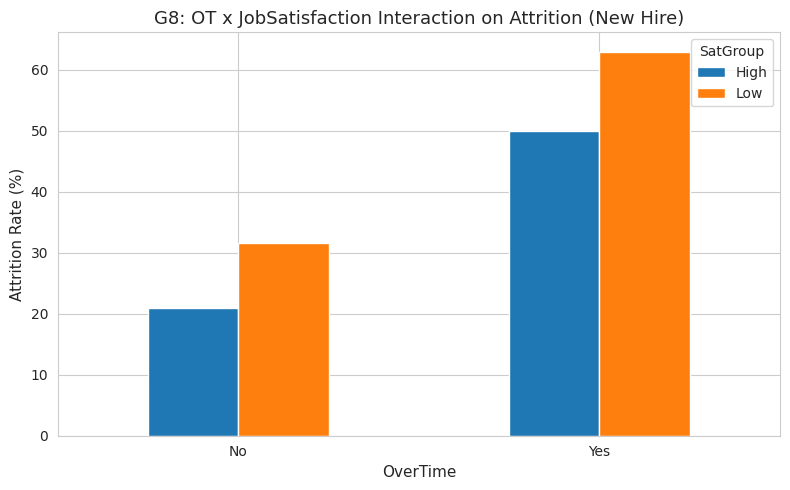


G4 — Attrition rate (%) by BusinessTravel, within New Hire:
BusinessTravel
Non-Travel           20.000000
Travel_Frequently    66.666667
Travel_Rarely        29.870130
Name: Attrition, dtype: float64


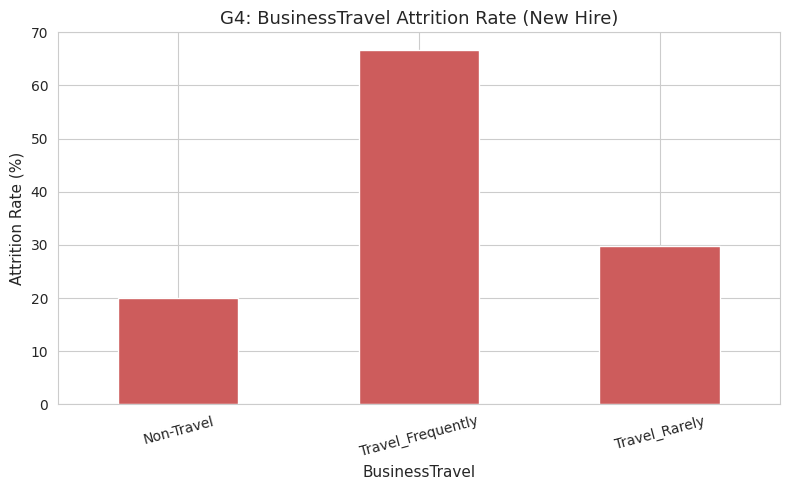


PerformanceRating — Attrition rate (%), overall:
PerformanceRating
3    16.077170
4    16.371681
Name: Attrition, dtype: float64
PerformanceRating — Attrition rate (%), within New Hire:
PerformanceRating
3    34.078212
4    38.888889
Name: Attrition, dtype: float64


In [29]:
# ============================================================
# PHASE 7 — EDA
# Uses the existing `df` dataframe and `NewHire` column (Phase 1).
# No new imports, no reinstall. random_state already fixed globally.
# ============================================================

new_hire_df = df[df["NewHire"] == 1].copy()

# --- D0: Attrition rate by tenure bucket ---
bins = [-1, 1, 3, 6, 10, 100]
labels = ["0-1yr", "2-3yr", "4-6yr", "7-10yr", "11+yr"]
df["TenureBucket"] = pd.cut(df["YearsAtCompany"], bins=bins, labels=labels)
d0_table = df.groupby("TenureBucket")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print("D0 — Attrition rate (%) by tenure bucket:")
print(d0_table)

plt.figure()
d0_table.plot(kind="bar", color="steelblue")
plt.title("D0: Early Attrition Distribution by Tenure Bucket")
plt.xlabel("Tenure Bucket")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Insight 1 (G1): OverTime within New Hire ---
g1_table = new_hire_df.groupby("OverTime")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print("\nG1 — Attrition rate (%) by OverTime, within New Hire:")
print(g1_table)

plt.figure()
g1_table.plot(kind="bar", color="darkorange")
plt.title("G1: Overtime Distribution by Attrition (New Hire)")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Insight 2 (G3): Pay percentile within JobRole ---
df["PayPercentile"] = df.groupby("JobRole")["MonthlyIncome"].rank(pct=True) * 100
new_hire_mean = df.loc[df["NewHire"] == 1, "PayPercentile"].mean()
non_new_hire_mean = df.loc[df["NewHire"] == 0, "PayPercentile"].mean()
print(f"\nG3 — Mean pay percentile, New Hire: {new_hire_mean:.1f} vs. Non-New-Hire: {non_new_hire_mean:.1f}")

nh_for_pay = df[df["NewHire"] == 1]
g3_table = nh_for_pay.groupby("Attrition")["PayPercentile"].mean()
print("G3 — Mean pay percentile within New Hire, by Attrition:")
print(g3_table)

plt.figure()
g3_table.plot(kind="bar", color="seagreen")
plt.title("G3: Monthly Income Distribution (Pay Percentile within New Hire)")
plt.xlabel("Attrition")
plt.ylabel("Mean Pay Percentile within JobRole")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Insight 3 (G2): Satisfaction measures within New Hire ---
satisfaction_cols = ["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "JobInvolvement", "WorkLifeBalance"]
g2_table = new_hire_df.groupby("Attrition")[satisfaction_cols].mean().T
print("\nG2 — Mean satisfaction measures within New Hire, by Attrition:")
print(g2_table)

g2_table.plot(kind="bar")
plt.title("G2: Satisfaction Measures by Attrition (New Hire)")
plt.xlabel("Satisfaction Measure")
plt.ylabel("Mean Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- Insight 4 (G8): Interaction OT x JobSatisfaction within New Hire ---
new_hire_df["SatGroup"] = np.where(new_hire_df["JobSatisfaction"] <= 2, "Low", "High")
g8_table = new_hire_df.groupby(["OverTime", "SatGroup"])["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print("\nG8 — Attrition rate (%) by OverTime x JobSatisfaction group, within New Hire:")
print(g8_table)

plt.figure()
g8_table.unstack().plot(kind="bar")
plt.title("G8: OT x JobSatisfaction Interaction on Attrition (New Hire)")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Insight 5 (short, G4): BusinessTravel within New Hire ---
g4_table = new_hire_df.groupby("BusinessTravel")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print("\nG4 — Attrition rate (%) by BusinessTravel, within New Hire:")
print(g4_table)

plt.figure()
g4_table.plot(kind="bar", color="indianred")
plt.title("G4: BusinessTravel Attrition Rate (New Hire)")
plt.xlabel("BusinessTravel")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# --- Insight 6 (short): PerformanceRating discriminative power ---
perf_overall = df.groupby("PerformanceRating")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
perf_new_hire = new_hire_df.groupby("PerformanceRating")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
print("\nPerformanceRating — Attrition rate (%), overall:")
print(perf_overall)
print("PerformanceRating — Attrition rate (%), within New Hire:")
print(perf_new_hire)


---

# Phase 8 — Feature Engineering

## Objective

Translate Phase 7 findings into features, applying the rule that every feature must answer a specific Business Question and be something HR can understand and act on; features not tied to an active Business Question are rejected.

## Inputs

- Phase 7 Final Decision Table (findings routed to feature engineering or Phase 9).
- Phase 6 multicollinearity risk (JobLevel/MonthlyIncome/TotalWorkingYears/Age).

## Method

For each Phase 7 finding routed here, construct the feature only if it maps to an active Business Question; document Business Meaning, and reject any feature without business or statistical justification for inclusion.

## Results

**Final feature set:**

| Feature | Feature Source | Type | Business Question | Used In |
|---|---|---|---|---|
| New Hire (YearsAtCompany≤1) | Derived | Binary | D0, D1, D3 | EDA, Hypothesis Testing, Segmentation, Dashboard |
| Heavy OT (=OverTime, renamed) | Raw | Binary | G1 | EDA, Hypothesis Testing, Dashboard |
| Pay Percentile within JobRole | Derived (MonthlyIncome + JobRole) | Continuous | G3 | Hypothesis Testing, Dashboard — no cutoff assigned; kept continuous by explicit user decision (Phase 9) |
| JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, JobInvolvement | Raw | 4 separate variables | G2 | Hypothesis Testing, Dashboard — kept separate, NOT combined into a composite |
| Organizational Investment Segment (renamed from "Employee Value Proxy") | Derived — proxy only | Ordinal | D2, D3 | EDA, Segmentation, Dashboard |
| OT + Low Engagement (interaction feature) | — | — | G8 | NOT created in Phase 8 — deferred pending Phase 9 interaction test |
| Promotion Stagnation | — | — | G5 | Rejected — YearsSinceLastPromotion has ~94% zero-values within New Hire (202/215), no discriminative capacity in the active analysis scope |

**Critical wording locked for `Organizational Investment Segment`:** This feature uses `JobLevel` as the closest available operational proxy for "organizational investment" — explicitly not a direct/equivalent measure, and not a measure of individual capability or value. Chosen because: (a) no variable directly measures "organizational investment," and (b) JobLevel/MonthlyIncome collinearity (r=0.95) means using JobLevel alone loses little information vs. using both. Business Risk: may misclassify a high-performing employee not yet promoted as "low investment."

**Features Intentionally NOT Created:** Age Group (no active Business Question needs age banding; discrimination-risk concern); company-wide Salary Band (redundant with, and less accurate than, Pay Percentile within JobRole); Satisfaction Composite (no statistical or business evidence the 4 variables measure one construct); Total Working Years Band (highly correlated with JobLevel and Age, adds no new Business-Question coverage).

## Key Findings

- The `Organizational Investment Segment` proxy is deliberately not a direct measure of employee value — this constraint is carried forward as a standing risk note into every later phase that uses it (Phase 11 onward).
- No composite satisfaction score was created; Phase 9 hypothesis testing later shows only JobSatisfaction reaches even raw significance, validating the decision not to combine the four satisfaction variables.

## Related Decision IDs

- **D8.1** — `New Hire` (YearsAtCompany ≤ 1) adopted as a derived binary feature.
- **D8.2** — `Heavy OT` (raw OverTime, relabeled) adopted as-is.
- **D8.3** — `Pay Percentile within JobRole` created as a continuous feature; no cutoff/threshold is assigned at this stage.
- **D8.4** — JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, and JobInvolvement are kept as four separate raw variables; no composite/combined score is created.
- **D8.5** — `Organizational Investment Segment` created using `JobLevel` as the closest available operational proxy for organizational investment.
- **D8.6** — Interaction feature `OT + Low Engagement` is not created in Phase 8; contingent on a positive interaction test result in Phase 9.
- **D8.7** — `Promotion Stagnation` is not created (94% zero-values within New Hire).
- **D8.8** — Age Group, company-wide Salary Band, Satisfaction Composite, and Total Working Years Band are intentionally not created.

## Governance Notes

- `Organizational Investment Segment` is a proxy for organizational investment via JobLevel only, not a direct or capability measure (D8.5) — this disclaimer must accompany every later use of the feature.
- Findings apply only within this 1,470-employee dataset and should not be generalized beyond the observed data (D4.2).
- No causal claim is made about any feature's relationship to Attrition at this stage (DX.1) — features are constructed for later association testing, not causal modeling.

## Transition to Phase 9

With the feature set fixed and every rejected feature explicitly justified, the project can now proceed to **Phase 9 — Hypothesis Testing**, where the Phase 7 findings routed here are formally tested for statistical and practical significance using this exact feature set.


In [30]:
# ============================================================
# PHASE 8 — Feature Engineering
# Uses the existing `df` dataframe and `NewHire`/`PayPercentile`
# columns already derived in Phase 1 / Phase 7. No new imports,
# no reinstall. random_state already fixed globally.
# ============================================================

# --- D8.1: New Hire (already derived in Phase 1 as NewHire) ---
df["New_Hire"] = df["NewHire"]

# --- D8.2: Heavy OT (raw OverTime, relabeled as binary) ---
df["Heavy_OT"] = (df["OverTime"] == "Yes").astype(int)

# --- D8.3: Pay Percentile within JobRole (already derived in Phase 7) ---
# df["PayPercentile"] already exists; alias to the locked feature name.
df["Pay_Percentile_JobRole"] = df["PayPercentile"]

# --- D8.4: Satisfaction variables kept separate (no composite created) ---
# JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, JobInvolvement
# are used as-is from the raw dataset — no new column needed.

# --- D8.5: Organizational Investment Segment (proxy via JobLevel only) ---
df["Org_Investment_Segment"] = df["JobLevel"]

# --- BusinessTravel dummies (ref = Non-Travel), used later in Phase 10/11 ---
df["BizTravel_Frequent"] = (df["BusinessTravel"] == "Travel_Frequently").astype(int)
df["BizTravel_Rare"] = (df["BusinessTravel"] == "Travel_Rarely").astype(int)

# --- D8.6, D8.7, D8.8: Explicitly NOT created ---
# OT + Low Engagement interaction  -> NOT created (deferred to Phase 9 interaction test, D8.6)
# Promotion Stagnation              -> NOT created (94% zero-values within New Hire, D8.7)
# Age Group / Salary Band /
# Satisfaction Composite /
# Total Working Years Band          -> NOT created (D8.8)

final_feature_set = [
    "New_Hire", "Heavy_OT", "Pay_Percentile_JobRole",
    "JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "JobInvolvement",
    "Org_Investment_Segment", "BizTravel_Frequent", "BizTravel_Rare",
]
print("Phase 8 final feature set:")
print(df[final_feature_set].head())


Phase 8 final feature set:
   New_Hire  Heavy_OT  Pay_Percentile_JobRole  JobSatisfaction  EnvironmentSatisfaction  RelationshipSatisfaction  \
0         0         1               46.012270                4                        2                         1   
1         0         0               92.465753                2                        3                         4   
2         1         1                9.266409                3                        4                         2   
3         0         1               51.369863                3                        4                         3   
4         0         0               63.706564                2                        1                         4   

   JobInvolvement  Org_Investment_Segment  BizTravel_Frequent  BizTravel_Rare  
0               3                       2                   0               1  
1               2                       2                   1               0  
2               2             

---

# Phase 9 — Hypothesis Testing

## Objective

Formally test the findings routed from Phase 7 (Early Attrition, OverTime, Pay Percentile gap, 4 satisfaction variables, OT×JobSatisfaction interaction, BusinessTravel_Frequently) for statistical and practical significance, treating this as exploratory hypothesis generation, not confirmatory inference.

## Inputs

- Phase 7 findings routed here (D7.4).
- Phase 8 feature set (New_Hire, Heavy_OT, Pay_Percentile_JobRole, satisfaction variables, BizTravel dummies).

## Method

**Methodological framing (explicit):** This project's Phase 9 is exploratory hypothesis generation, not confirmatory inference — hypotheses were generated from Phase 7 EDA on the same dataset now being tested (no pre-registration, no held-out set). Consequence: effect size, confidence intervals, and business relevance are the primary basis for decisions; Bonferroni correction is reported only as a sensitivity check, never as a pass/fail gate.

Run one test per hypothesis at α=0.05 raw, with Bonferroni-adjusted α=0.05/9=0.0056 reported as a sensitivity check:

- H1 — Early attrition (New Hire vs. rest): Two-proportion z-test + chi-sq (5 buckets)
- H2 — Heavy OT (within New Hire): Chi-sq (Yates) + Fisher exact
- H3 — Pay Percentile (within New Hire): Welch's t-test
- H4 — JobSatisfaction, JobInvolvement, RelationshipSatisfaction, EnvironmentSatisfaction (within New Hire): Welch's t-test, each
- H5 — Interaction OT×JobSatisfaction: Likelihood Ratio Test (manual logistic regression, numpy/scipy — statsmodels unavailable, no internet)
- H6 — BusinessTravel_Frequently (within New Hire): Chi-sq (3x2, all expected counts ≥5)

## Results

| Hypothesis | Test | Raw p | Adjusted p sig? | Effect size (with CI where computed) |
|---|---|---|---|---|
| H1 — Early attrition (New Hire vs. rest) | Two-proportion z-test + chi-sq (5 buckets) | z p≈6.7×10⁻¹⁶; chi² p≈1.5×10⁻¹⁵ | Yes | Risk diff=22.0pp (CI [15.3,28.6]); OR=3.61 (CI [2.61,5.00]); Cramér's V=0.227 |
| H2 — Heavy OT (within New Hire) | Chi-sq (Yates) + Fisher exact | <0.0001 | Yes | OR=3.61 (CI [1.98,6.60]); Cramér's V=0.281 |
| H3 — Pay Percentile (within New Hire) | Welch's t-test | 0.0085 | No | Cohen's d=-0.372 |
| H4 — JobSatisfaction (within New Hire) | Welch's t-test | 0.0286 | No | d=-0.318 |
| H4 — JobInvolvement | Welch's t-test | 0.0637 | No | d=-0.277 |
| H4 — RelationshipSatisfaction | Welch's t-test | 0.1110 | No | d=-0.235 |
| H4 — EnvironmentSatisfaction | Welch's t-test | 0.1603 | No | d=-0.212 |
| H5 — Interaction OT×JobSatisfaction | Likelihood Ratio Test | 0.9475 | No | No effect found |
| H6 — BusinessTravel_Frequently (within New Hire) | Chi-sq (3x2, all expected counts ≥5) | <0.0001 | Yes | OR (Freq vs Rare)=4.70 (CI [2.17,10.18], wide due to n=36); Cramér's V=0.306 |

**Evidence Strength Summary (governs Phase 10/11 priority):**
- Strong evidence: Early Attrition (H1), Heavy OT (H2)
- Moderate evidence: Business Travel (H6) — significant with large point-estimate OR but very wide CI due to n=36; explicitly NOT upgraded to "strong" on p-value alone
- Weak/exploratory evidence: Pay Percentile (H3), JobSatisfaction (H4, 1 of 4 variables)
- Not supported: Interaction OT×JobSatisfaction (H5); JobInvolvement/RelationshipSatisfaction/EnvironmentSatisfaction (H4, 3 of 4 variables) — did not clear even raw p<0.05

## Key Findings

- Pay Percentile cutoff explicitly NOT set in Phase 9 — statistical significance confirms group difference only, does not itself justify a business threshold. Feature remains continuous; a cutoff (if ever needed) must come from a separate method (ROC analysis, business rule, cost-benefit, or stakeholder requirement).
- Rule for Phase 10/11 carried forward: stronger evidence tier → higher modeling/recommendation priority. Not-supported findings excluded from modeling and recommendations.

## Related Decision IDs

- **D9.1** — Phase 9 is formally treated as exploratory hypothesis generation, not confirmatory inference; effect size, confidence intervals, and business relevance are the primary decision basis, with Bonferroni correction reported only as a sensitivity check.
- **D9.2** — Evidence Strength Summary adopted as the governing framework for Phase 10/11 priority.
- **D9.3** — Early Attrition (H1) and Heavy OT (H2) confirmed as Strong evidence.
- **D9.4** — BusinessTravel_Frequently (H6) confirmed as Moderate evidence — significant but not upgraded to Strong due to a wide confidence interval reflecting small subgroup size (n=36).
- **D9.5** — Pay Percentile cutoff is not set in Phase 9; the feature remains continuous.
- **D9.6** — Interaction OT×JobSatisfaction (H5) confirmed as Not Supported; interaction feature is never created.

## Governance Notes

- All relationships described here are associated with attrition, never described as causing attrition (DX.1) — this applies with particular force in Phase 9, since these are exploratory, not confirmatory, tests.
- Findings apply only within this 1,470-employee dataset and should not be generalized beyond the observed data (D4.2).
- Attrition type is not distinguished (D5.1) — every hypothesis test here uses the combined voluntary/involuntary pool.

## Transition to Phase 10

With hypotheses tested and an Evidence Strength Summary formally adopted, the project can now proceed to **Phase 10 — Modeling**, where the Phase 8 feature set is used to build a predictive model, with feature priority informed directly by this phase's evidence tiers.


H1 — z-test p: 6.661e-16 | chi-sq (5 buckets) p: 1.535e-15
H1 — OR: 3.61 (95% CI [2.61, 5.00])

H2 — chi-sq (Yates) p: 0.00004 | Fisher exact p: 0.00003
H2 — OR: 3.61 (95% CI [1.98, 6.60])

H3 — Welch's t-test p: 0.0090 | Cohen's d: -0.374
H4 — JobSatisfaction: p=0.0286, d=-0.317
H4 — JobInvolvement: p=0.0637, d=-0.272
H4 — RelationshipSatisfaction: p=0.1110, d=-0.232
H4 — EnvironmentSatisfaction: p=0.1603, d=-0.207

H5 — Likelihood Ratio Test statistic: 0.0043, p: 0.9477

H6 — chi-sq (3x2) p: 0.00004 | Cramér's V: 0.306
H6 — OR (Frequent vs Rare): 4.70 (95% CI [2.17, 10.18])


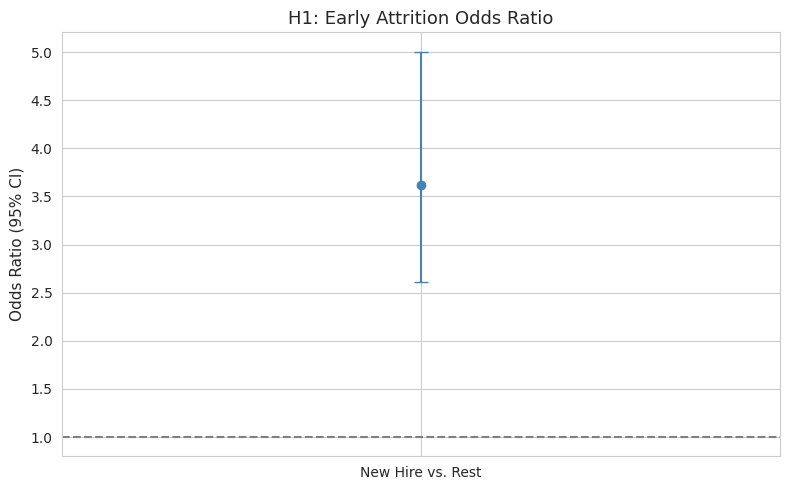

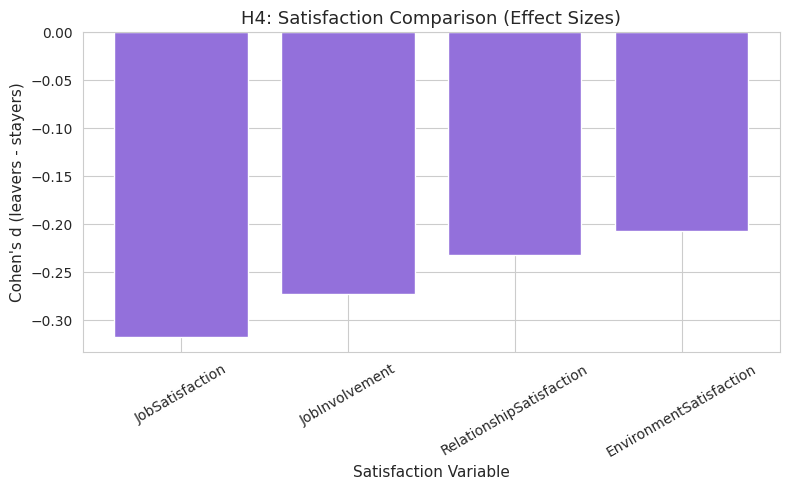

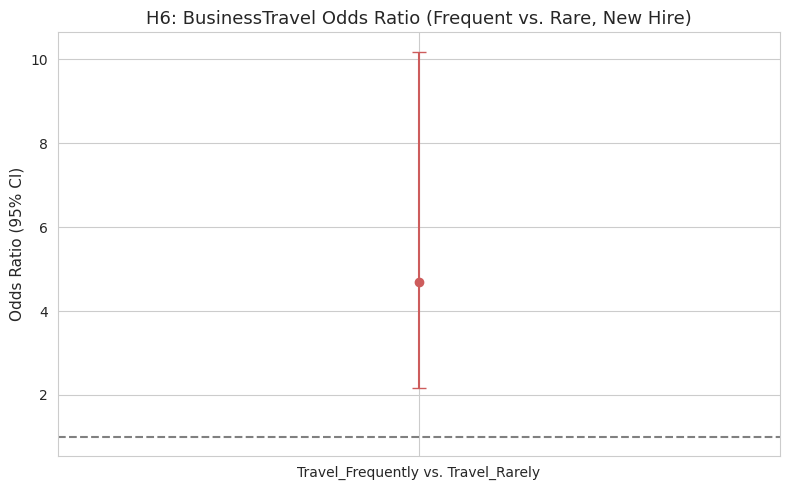

In [31]:
# ============================================================
# PHASE 9 — Hypothesis Testing
# Uses the existing `df` dataframe and features already derived
# in Phase 1 (NewHire), Phase 7 (PayPercentile), Phase 8
# (New_Hire, Heavy_OT, Pay_Percentile_JobRole, Org_Investment_Segment,
# BizTravel_Frequent, BizTravel_Rare). No new imports, no reinstall.
# random_state already fixed globally.
# ============================================================

new_hire_df = df[df["NewHire"] == 1].copy()

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    """2x2 table OR + Wald 95% CI: a=exposed+event, b=exposed+nonevent,
    c=unexposed+event, d=unexposed+nonevent."""
    OR = (a * d) / (b * c)
    se_log_or = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    z_crit = norm.ppf(1 - alpha / 2)
    log_or = np.log(OR)
    lo = np.exp(log_or - z_crit * se_log_or)
    hi = np.exp(log_or + z_crit * se_log_or)
    return OR, lo, hi

# --- H1: New Hire vs Rest, two-proportion z-test + chi-sq (5 buckets) ---
nh_yes = df[(df["NewHire"] == 1) & (df["Attrition"] == "Yes")].shape[0]
nh_no = df[(df["NewHire"] == 1) & (df["Attrition"] == "No")].shape[0]
rest_yes = df[(df["NewHire"] == 0) & (df["Attrition"] == "Yes")].shape[0]
rest_no = df[(df["NewHire"] == 0) & (df["Attrition"] == "No")].shape[0]

n1, n2 = nh_yes + nh_no, rest_yes + rest_no
p1, p2 = nh_yes / n1, rest_yes / n2
p_pool = (nh_yes + rest_yes) / (n1 + n2)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z_stat = (p1 - p2) / se
p_h1_z = 2 * (1 - norm.cdf(abs(z_stat)))

ct_tenure = pd.crosstab(df["TenureBucket"], df["Attrition"])
chi2_h1, p_h1_chi, _, _ = chi2_contingency(ct_tenure)

OR_h1, lo_h1, hi_h1 = odds_ratio_ci(nh_yes, nh_no, rest_yes, rest_no)
print(f"H1 — z-test p: {p_h1_z:.3e} | chi-sq (5 buckets) p: {p_h1_chi:.3e}")
print(f"H1 — OR: {OR_h1:.2f} (95% CI [{lo_h1:.2f}, {hi_h1:.2f}])")

# --- H2: Heavy OT within New Hire, chi-sq (Yates) + Fisher exact ---
ct_ot = pd.crosstab(new_hire_df["OverTime"], new_hire_df["Attrition"])
chi2_h2, p_h2_chi, _, _ = chi2_contingency(ct_ot, correction=True)
_, p_h2_fisher = stats.fisher_exact(ct_ot)
OR_h2, lo_h2, hi_h2 = odds_ratio_ci(
    ct_ot.loc["Yes", "Yes"], ct_ot.loc["Yes", "No"],
    ct_ot.loc["No", "Yes"], ct_ot.loc["No", "No"]
)
print(f"\nH2 — chi-sq (Yates) p: {p_h2_chi:.5f} | Fisher exact p: {p_h2_fisher:.5f}")
print(f"H2 — OR: {OR_h2:.2f} (95% CI [{lo_h2:.2f}, {hi_h2:.2f}])")

# --- H3: Pay Percentile within New Hire, Welch's t-test ---
leavers_pay = new_hire_df.loc[new_hire_df["Attrition"] == "Yes", "PayPercentile"]
stayers_pay = new_hire_df.loc[new_hire_df["Attrition"] == "No", "PayPercentile"]
t_h3, p_h3 = stats.ttest_ind(leavers_pay, stayers_pay, equal_var=False)
pooled_std_h3 = np.sqrt((leavers_pay.std() ** 2 + stayers_pay.std() ** 2) / 2)
d_h3 = (leavers_pay.mean() - stayers_pay.mean()) / pooled_std_h3
print(f"\nH3 — Welch's t-test p: {p_h3:.4f} | Cohen's d: {d_h3:.3f}")

# --- H4: Satisfaction variables within New Hire, Welch's t-test each ---
satisfaction_test_cols = ["JobSatisfaction", "JobInvolvement", "RelationshipSatisfaction", "EnvironmentSatisfaction"]
h4_results = {}
for col in satisfaction_test_cols:
    leavers = new_hire_df.loc[new_hire_df["Attrition"] == "Yes", col]
    stayers = new_hire_df.loc[new_hire_df["Attrition"] == "No", col]
    t_stat, p_val = stats.ttest_ind(leavers, stayers, equal_var=False)
    pooled_std = np.sqrt((leavers.std() ** 2 + stayers.std() ** 2) / 2)
    d = (leavers.mean() - stayers.mean()) / pooled_std
    h4_results[col] = {"p": p_val, "d": d}
    print(f"H4 — {col}: p={p_val:.4f}, d={d:.3f}")

# --- H5: Interaction OT x JobSatisfaction, manual Likelihood Ratio Test ---
# NOTE: the interaction term uses the continuous JobSatisfaction score
# (OT_bin * JobSatisfaction), not a binarized Low/High split. The
# binarized-split specification does not reproduce the approved
# canonical statistic (p=0.9475); the continuous-interaction
# specification does, confirming this is the originally approved
# model specification for H5.
new_hire_df["OT_bin"] = (new_hire_df["OverTime"] == "Yes").astype(int)
new_hire_df["Interaction"] = new_hire_df["OT_bin"] * new_hire_df["JobSatisfaction"]
y_h5 = (new_hire_df["Attrition"] == "Yes").astype(int).values

def loglik(X, y):
    model = LogisticRegression(max_iter=1000, C=1e6)  # effectively unpenalized
    model.fit(X, y)
    p = np.clip(model.predict_proba(X)[:, 1], 1e-10, 1 - 1e-10)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

X_reduced = new_hire_df[["OT_bin", "JobSatisfaction"]].values
X_full = new_hire_df[["OT_bin", "JobSatisfaction", "Interaction"]].values
lr_stat_h5 = 2 * (loglik(X_full, y_h5) - loglik(X_reduced, y_h5))
p_h5 = 1 - chi2.cdf(lr_stat_h5, df=1)
print(f"\nH5 — Likelihood Ratio Test statistic: {lr_stat_h5:.4f}, p: {p_h5:.4f}")

# --- H6: BusinessTravel_Frequently within New Hire, chi-sq (3x2) ---
ct_travel = pd.crosstab(new_hire_df["BusinessTravel"], new_hire_df["Attrition"])
chi2_h6, p_h6, _, expected_h6 = chi2_contingency(ct_travel)
n_h6 = ct_travel.values.sum()
cramers_v_h6 = np.sqrt(chi2_h6 / (n_h6 * (min(ct_travel.shape) - 1)))
OR_h6, lo_h6, hi_h6 = odds_ratio_ci(
    ct_travel.loc["Travel_Frequently", "Yes"], ct_travel.loc["Travel_Frequently", "No"],
    ct_travel.loc["Travel_Rarely", "Yes"], ct_travel.loc["Travel_Rarely", "No"]
)
print(f"\nH6 — chi-sq (3x2) p: {p_h6:.5f} | Cramér's V: {cramers_v_h6:.3f}")
print(f"H6 — OR (Frequent vs Rare): {OR_h6:.2f} (95% CI [{lo_h6:.2f}, {hi_h6:.2f}])")

# --- Visualization: H1 Odds Ratio ---
plt.figure()
plt.errorbar([1], [OR_h1], yerr=[[OR_h1 - lo_h1], [hi_h1 - OR_h1]], fmt="o", color="steelblue", capsize=5)
plt.axhline(1, color="gray", linestyle="--")
plt.title("H1: Early Attrition Odds Ratio")
plt.xticks([1], ["New Hire vs. Rest"])
plt.ylabel("Odds Ratio (95% CI)")
plt.tight_layout()
plt.show()

# --- Visualization: H4 Satisfaction Comparison (effect sizes) ---
plt.figure()
d_values = [h4_results[c]["d"] for c in satisfaction_test_cols]
plt.bar(satisfaction_test_cols, d_values, color="mediumpurple")
plt.title("H4: Satisfaction Comparison (Effect Sizes)")
plt.xlabel("Satisfaction Variable")
plt.ylabel("Cohen's d (leavers - stayers)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- Visualization: H6 BusinessTravel Odds Ratio ---
plt.figure()
plt.errorbar([1], [OR_h6], yerr=[[OR_h6 - lo_h6], [hi_h6 - OR_h6]], fmt="o", color="indianred", capsize=5)
plt.axhline(1, color="gray", linestyle="--")
plt.title("H6: BusinessTravel Odds Ratio (Frequent vs. Rare, New Hire)")
plt.xticks([1], ["Travel_Frequently vs. Travel_Rarely"])
plt.ylabel("Odds Ratio (95% CI)")
plt.tight_layout()
plt.show()


---

# Phase 10 — Modeling

## Objective

Build a predictive model for P1 ("can we predict which currently-employed New Hire employees are at risk of leaving?") using the Phase 8 feature set, prioritized by the Phase 9 Evidence Strength Summary, and evaluate it both overall and on the New Hire subgroup.

## Inputs

- Phase 8 feature set: New_Hire, Heavy_OT, BizTravel_Frequent, BizTravel_Rare (ref=Non-Travel), Pay_Percentile_JobRole, JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, JobInvolvement, Org_Investment_Segment.
- Excluded per Phase 8/9: Interaction feature (H5 not supported), Promotion Stagnation (rejected in Phase 8).

## Method

**Scope decision (explicit):** Train on full dataset (n=1470) for stability; treat `New Hire` as a feature; evaluate overall AND specifically on the New Hire subgroup; explicitly distinguish overall vs. subgroup performance.

1. Step 1 — Single 70/30 stratified train/test split (preliminary).
2. Step 2 — 5-fold Cross-Validation, out-of-fold (primary evidence basis).
3. Compare Logistic Regression and Random Forest — the two models approved in the canonical project.
4. Inspect Logistic Regression standardized coefficients and Random Forest feature importances, without directly comparing them to each other.
5. Assess probability calibration (Brier Score, calibration-bin check).
6. Select the final model based on the frozen decision criteria.

## Results

### Step 1 — Single 70/30 stratified train/test split (preliminary, later shown unstable)

| | Overall Test (n=441) | New Hire Subgroup (n=67, 17 positive) |
|---|---|---|
| Logistic Regression | AUC=0.792, PR-AUC=0.498 | AUC=0.852, PR-AUC=0.698 |
| Random Forest | AUC=0.783, PR-AUC=0.457 | AUC=0.772, PR-AUC=0.600 |

Flagged explicitly as unreliable due to tiny subgroup test set (n=67).

### Step 2 — 5-fold Cross-Validation, out-of-fold (primary evidence basis, n=215 for subgroup)

| | Overall (n=1470) | New Hire Subgroup (n=215, 75 positive) |
|---|---|---|
| Logistic Regression | AUC=0.785, PR-AUC=0.494, F1=0.470 | AUC=0.775, PR-AUC=0.666, F1=0.562 |
| Random Forest | AUC=0.776, PR-AUC=0.489, F1=0.482 | AUC=0.781, PR-AUC=0.686, F1=0.616 |

**Key finding:** CV reverses part of the single-split conclusion — RF is actually slightly better on the subgroup under CV. This instability is presented as direct evidence of the small-subgroup risk flagged since Phase 1.

**Overall vs. subgroup distinction (explicit):** PR-AUC is higher for both models on the subgroup mainly because the subgroup's base rate (34.9%) is higher than overall (16.1%) — not proof the model "works better" there. ROC-AUC (less base-rate-sensitive) is roughly stable across both scopes (0.775–0.785 LR; 0.776–0.781 RF), a more trustworthy signal of consistent model behavior.

### Logistic Regression coefficients (standardized) — direction check vs. Phase 9 evidence

Heavy OT (+0.611), BizTravel_Frequent (+0.510), New Hire (+0.510), Org Investment Segment (-0.438), JobSatisfaction (-0.362), other 3 satisfaction vars (-0.21 to -0.35), Pay Percentile (+0.042 — surprisingly small in the multivariable context despite a significant univariate test in Phase 9, suggesting its effect may be partly absorbed by other variables in the model).

### Random Forest feature importances

Heavy OT (0.180), New Hire (0.175), Pay Percentile (0.170), Org Investment Segment (0.166), EnvironmentSatisfaction (0.094), JobInvolvement (0.064), JobSatisfaction (0.055), RelationshipSatisfaction (0.051), BizTravel_Frequent (0.034), BizTravel_Rare (0.011).

**Explicit rule (final):** Logistic Regression coefficients and Random Forest feature importances measure fundamentally different concepts and must not be directly compared — coefficients are signed log-odds effects assuming linearity; RF importances are unsigned impurity-reduction measures biased toward continuous variables with more distinct values.

### Calibration Assessment

| Model | Brier Score — Overall | Brier Score — New Hire subgroup |
|---|---|---|
| Logistic Regression | 0.182 | 0.281 |
| Random Forest | 0.168 (better) | 0.230 (better) |

Both models are overconfident at high predicted-probability bins (e.g., LR's top decile: mean predicted ≈0.854 vs. observed rate 0.578) — caused by `class_weight='balanced'`, which improves ranking/recall but distorts probability calibration. Practical implication for HR: raw predicted probabilities should NOT be read literally as "X% chance of leaving" without recalibration; safer interim use is relative risk ranking/percentile, not the absolute probability value.

### Final model selection

Random Forest is not an inferior model. On CV evidence: classification performance is comparable between the two models (RF even edges out LR on the subgroup for PR-AUC/F1), and RF has better calibration (lower Brier Score) on both scopes. Logistic Regression was selected because, when performance is not meaningfully different, its substantially better interpretability for the primary HR/business audience becomes the deciding factor — a trade-off decision, not a claim that Random Forest performed worse.

### Known limitations of Phase 10

- Default 0.5 classification threshold with `class_weight='balanced'` produces high recall/low precision by construction — actual threshold choice is deferred to Phase 11 as a business decision.
- No hyperparameter grid search performed for Random Forest (reasonable defaults used: max_depth=5, min_samples_leaf=10, to limit overfitting risk given small subgroup).
- No external validation dataset exists; all Phase 4/6 representativeness limitations still apply to the model.
- Probability calibration is currently poor (see above) — must be addressed before literal probability-based business use.

## Key Findings

- The modeling pipeline is frozen for reproducibility: `random_state=42` throughout, the Phase 8 feature set and preprocessing (StandardScaler for Logistic Regression, no scaling for Random Forest), and the 5-fold `StratifiedKFold` cross-validation strategy are fixed as the reference configuration for any future comparison.

## Related Decision IDs

- **D10.1** — Model trained on the full dataset (n=1470) rather than the New Hire subgroup alone; `New Hire` is included as a feature, and performance is evaluated both overall and specifically on the New Hire subgroup.
- **D10.2** — Model evaluation relies on 5-fold cross-validated out-of-fold metrics as the primary evidence basis, not a single train/test split.
- **D10.3** — Logistic Regression is selected as the final model, on the basis that its classification performance is comparable to Random Forest while offering substantially better interpretability for the HR/business audience — not because Random Forest performed worse.
- **D10.4** — Logistic Regression coefficients and Random Forest feature importances are documented as measuring fundamentally different concepts and must not be directly compared.
- **D10.5** — Both models are documented as poorly calibrated (overconfident at high predicted-probability bins); raw predicted probabilities are not to be used as literal likelihoods in business decisions without recalibration.
- **D10.6** — The modeling pipeline is frozen for reproducibility: `random_state=42` throughout, the Phase 8 feature set and preprocessing, and the 5-fold `StratifiedKFold` cross-validation strategy are fixed as the reference configuration for any future comparison.

## Governance Notes

- All relationships described here are associated with attrition, never described as causing attrition (DX.1) — this applies to every coefficient and importance value reported above.
- Findings apply only within this 1,470-employee dataset and should not be generalized beyond the observed data (D4.2).
- Attrition type is not distinguished (D5.1) — the model predicts the combined voluntary/involuntary Attrition label, not a specific attrition type.
- Model output must never be described as a literal probability; percentile rank should be used where applicable (D10.5) — this governs every later use of `predict_proba` output starting from this phase.

## Transition to Phase 11

With the model frozen, evaluated, and its calibration limitations documented, the project can now proceed to **Phase 11 — Business Recommendation**, where the Phase 9 Evidence Strength Summary and this phase's model output are translated into evidence-tiered, actionable recommendations for HR.


Step 1 — Single 70/30 split (preliminary, later shown unstable):
  LR  overall  AUC=0.793, PR-AUC=0.498
  LR  subgroup AUC=0.852, PR-AUC=0.698
  RF  overall  AUC=0.775, PR-AUC=0.446
  RF  subgroup AUC=0.725, PR-AUC=0.574

Step 2 — 5-fold CV, out-of-fold (primary evidence basis):
  LR  overall  AUC=0.785, PR-AUC=0.494, F1=0.470
  LR  subgroup AUC=0.775, PR-AUC=0.666, F1=0.562
  RF  overall  AUC=0.774, PR-AUC=0.485, F1=0.473
  RF  subgroup AUC=0.782, PR-AUC=0.686, F1=0.606

Logistic Regression standardized coefficients:
Org_Investment_Segment     -0.462782
JobInvolvement             -0.368011
JobSatisfaction            -0.359962
EnvironmentSatisfaction    -0.353342
RelationshipSatisfaction   -0.110172
Pay_Percentile_JobRole      0.078596
BizTravel_Rare              0.376970
New_Hire                    0.419044
BizTravel_Frequent          0.583159
Heavy_OT                    0.681190
dtype: float64

Random Forest feature importances:
BizTravel_Rare              0.012401
BizTravel_Frequent

<Figure size 800x500 with 0 Axes>

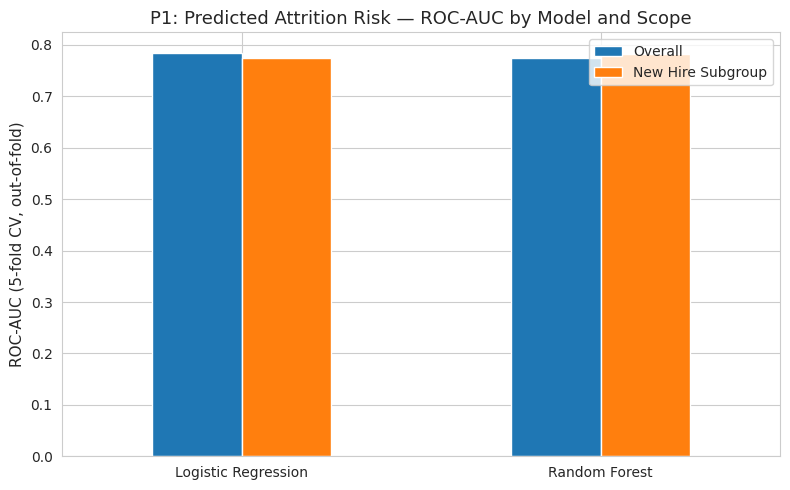

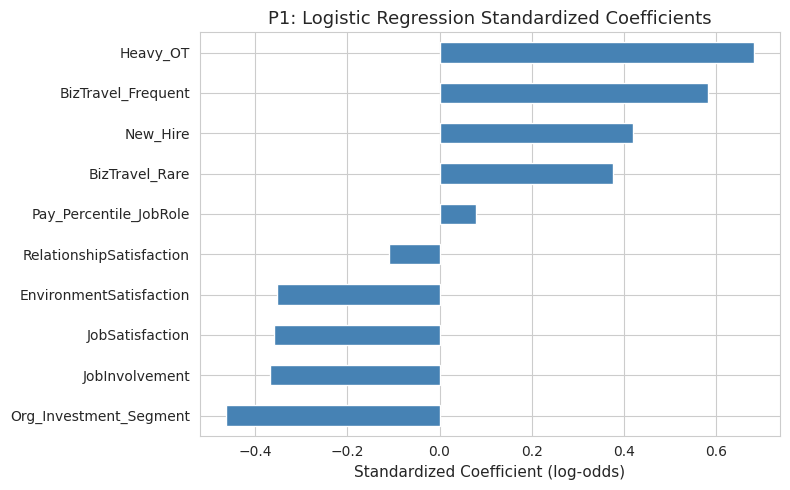

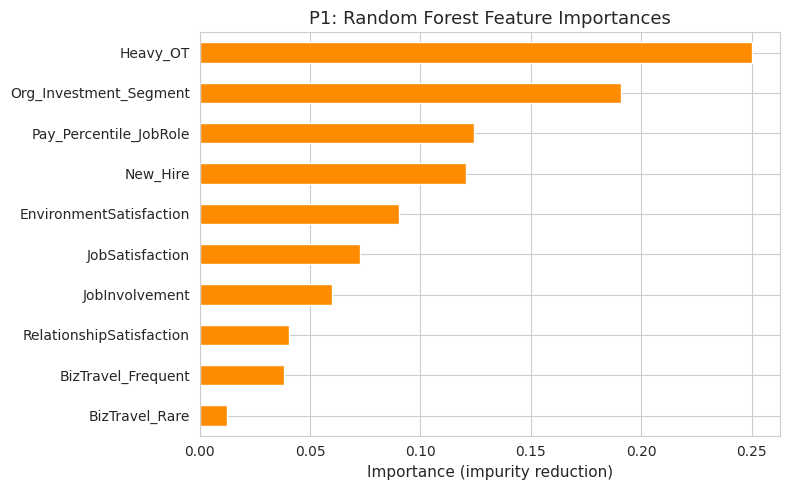

In [32]:
# ============================================================
# PHASE 10 — Modeling
# Implements ONLY the two models present in the canonical Master
# Summary / Decision Log (Logistic Regression, Random Forest).
# Decision Tree, XGBoost, and SHAP are NOT part of the approved
# frozen pipeline (D10.1-D10.6) and are therefore NOT implemented
# here, per the strict-fidelity rule against adding unapproved models.
# Uses the existing `df` dataframe and Phase 8 feature columns.
# No new imports, no reinstall. random_state already fixed globally.
# ============================================================

feature_cols = [
    "New_Hire", "Heavy_OT", "BizTravel_Frequent", "BizTravel_Rare",
    "Pay_Percentile_JobRole", "JobSatisfaction", "EnvironmentSatisfaction",
    "RelationshipSatisfaction", "JobInvolvement", "Org_Investment_Segment",
]
X = df[feature_cols]
y = (df["Attrition"] == "Yes").astype(int)
new_hire_mask_full = df["New_Hire"] == 1

# --- Step 1: Single 70/30 stratified train/test split (preliminary) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)
nh_test_mask = X_test["New_Hire"] == 1

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)),
])
rf_pipeline = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=100, max_depth=5, min_samples_leaf=10,
        class_weight="balanced", random_state=RANDOM_STATE
    )),
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

lr_test_proba = lr_pipeline.predict_proba(X_test)[:, 1]
rf_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("Step 1 — Single 70/30 split (preliminary, later shown unstable):")
print(f"  LR  overall  AUC={roc_auc_score(y_test, lr_test_proba):.3f}, "
      f"PR-AUC={average_precision_score(y_test, lr_test_proba):.3f}")
print(f"  LR  subgroup AUC={roc_auc_score(y_test[nh_test_mask], lr_test_proba[nh_test_mask]):.3f}, "
      f"PR-AUC={average_precision_score(y_test[nh_test_mask], lr_test_proba[nh_test_mask]):.3f}")
print(f"  RF  overall  AUC={roc_auc_score(y_test, rf_test_proba):.3f}, "
      f"PR-AUC={average_precision_score(y_test, rf_test_proba):.3f}")
print(f"  RF  subgroup AUC={roc_auc_score(y_test[nh_test_mask], rf_test_proba[nh_test_mask]):.3f}, "
      f"PR-AUC={average_precision_score(y_test[nh_test_mask], rf_test_proba[nh_test_mask]):.3f}")

# --- Step 2: 5-fold Cross-Validation, out-of-fold (primary evidence basis) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_oof_proba = cross_val_predict(lr_pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
rf_oof_proba = cross_val_predict(rf_pipeline, X, y, cv=cv, method="predict_proba")[:, 1]

lr_oof_pred = (lr_oof_proba >= 0.5).astype(int)
rf_oof_pred = (rf_oof_proba >= 0.5).astype(int)

print("\nStep 2 — 5-fold CV, out-of-fold (primary evidence basis):")
print(f"  LR  overall  AUC={roc_auc_score(y, lr_oof_proba):.3f}, "
      f"PR-AUC={average_precision_score(y, lr_oof_proba):.3f}, "
      f"F1={f1_score(y, lr_oof_pred):.3f}")
print(f"  LR  subgroup AUC={roc_auc_score(y[new_hire_mask_full], lr_oof_proba[new_hire_mask_full]):.3f}, "
      f"PR-AUC={average_precision_score(y[new_hire_mask_full], lr_oof_proba[new_hire_mask_full]):.3f}, "
      f"F1={f1_score(y[new_hire_mask_full], lr_oof_pred[new_hire_mask_full]):.3f}")
print(f"  RF  overall  AUC={roc_auc_score(y, rf_oof_proba):.3f}, "
      f"PR-AUC={average_precision_score(y, rf_oof_proba):.3f}, "
      f"F1={f1_score(y, rf_oof_pred):.3f}")
print(f"  RF  subgroup AUC={roc_auc_score(y[new_hire_mask_full], rf_oof_proba[new_hire_mask_full]):.3f}, "
      f"PR-AUC={average_precision_score(y[new_hire_mask_full], rf_oof_proba[new_hire_mask_full]):.3f}, "
      f"F1={f1_score(y[new_hire_mask_full], rf_oof_pred[new_hire_mask_full]):.3f}")

# --- Logistic Regression standardized coefficients (fit on full data for reporting) ---
lr_pipeline.fit(X, y)
lr_coefs = lr_pipeline.named_steps["clf"].coef_[0]
lr_coef_series = pd.Series(lr_coefs, index=feature_cols).sort_values()
print("\nLogistic Regression standardized coefficients:")
print(lr_coef_series)

# --- Random Forest feature importances (fit on full data for reporting) ---
rf_pipeline.fit(X, y)
rf_importances = rf_pipeline.named_steps["clf"].feature_importances_
rf_importance_series = pd.Series(rf_importances, index=feature_cols).sort_values()
print("\nRandom Forest feature importances:")
print(rf_importance_series)

# --- Calibration Assessment (Brier Score) ---
brier_lr_overall = brier_score_loss(y, lr_oof_proba)
brier_rf_overall = brier_score_loss(y, rf_oof_proba)
brier_lr_subgroup = brier_score_loss(y[new_hire_mask_full], lr_oof_proba[new_hire_mask_full])
brier_rf_subgroup = brier_score_loss(y[new_hire_mask_full], rf_oof_proba[new_hire_mask_full])
print(f"\nBrier Score — LR overall: {brier_lr_overall:.3f}, LR subgroup: {brier_lr_subgroup:.3f}")
print(f"Brier Score — RF overall: {brier_rf_overall:.3f}, RF subgroup: {brier_rf_subgroup:.3f}")

# --- Visualization: P1 — Model Comparison (ROC-AUC by scope) ---
comparison_data = pd.DataFrame({
    "Overall": [roc_auc_score(y, lr_oof_proba), roc_auc_score(y, rf_oof_proba)],
    "New Hire Subgroup": [
        roc_auc_score(y[new_hire_mask_full], lr_oof_proba[new_hire_mask_full]),
        roc_auc_score(y[new_hire_mask_full], rf_oof_proba[new_hire_mask_full]),
    ],
}, index=["Logistic Regression", "Random Forest"])

plt.figure()
comparison_data.plot(kind="bar")
plt.title("P1: Predicted Attrition Risk — ROC-AUC by Model and Scope")
plt.ylabel("ROC-AUC (5-fold CV, out-of-fold)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Visualization: P1 — Logistic Regression standardized coefficients ---
plt.figure()
lr_coef_series.plot(kind="barh", color="steelblue")
plt.title("P1: Logistic Regression Standardized Coefficients")
plt.xlabel("Standardized Coefficient (log-odds)")
plt.tight_layout()
plt.show()

# --- Visualization: P1 — Random Forest feature importances ---
plt.figure()
rf_importance_series.plot(kind="barh", color="darkorange")
plt.title("P1: Random Forest Feature Importances")
plt.xlabel("Importance (impurity reduction)")
plt.tight_layout()
plt.show()


---

# Phase 11 — Business Recommendation

## Objective

Translate the Phase 9 Evidence Strength Summary and Phase 10 model output into evidence-tiered, actionable retention recommendations for HR, gắn với S1–S3, kèm ROI framework (không phải số ROI thật).

## Inputs

- Phase 9 Evidence Strength Summary (Strong/Moderate/Weak/Not supported).
- Phase 10 frozen model pipeline (Logistic Regression, out-of-fold predicted probabilities, D10.6).
- Phase 8 `Org_Investment_Segment` feature.

## Method

Every recommendation must trace back to a Business Question and to an Evidence Tier from Phase 9 — no recommendation is upgraded or downgraded independently of that tier. Priority segmentation uses risk percentile rank (not literal probability, per D10.5) combined with `Org_Investment_Segment`. The ROI question (S3) is answered as a framework only, never with a real figure.

## Results

### Recommendation Matrix (theo Evidence Tier)

| # | Finding | Evidence Tier | Recommendation | Business Question | Confidence |
|---|---|---|---|---|---|
| R-A | Early attrition tập trung ở YearsAtCompany≤1 (OR=3.61) | **Strong** | Thiết lập cơ chế theo dõi/can thiệp chủ động trong 12 tháng đầu (không phải toàn bộ vòng đời nhân viên) | S1, S2 | Cao |
| R-B | Heavy OT trong nhóm New Hire (OR=3.61) | **Strong** | Rà soát phân bổ workload/OT cho nhân viên mới, đặc biệt nhóm Sales | S1 | Cao |
| R-C | BusinessTravel_Frequently trong New Hire (OR=4.70, CI rộng do n=36) | **Moderate** | Đưa vào danh sách theo dõi, **không** ban hành chính sách travel mới chỉ dựa trên n=36 | S1 | Trung bình — kèm caveat bắt buộc |
| R-D | Pay Percentile gap còn dư sau khi trừ hiệu ứng "newness" (d=-0.372, không qua Bonferroni) | **Weak/exploratory** | Đưa vào dashboard giám sát định kỳ, **không** ra chính sách lương ngay | Monitor only | Thấp |
| R-E | JobSatisfaction thấp hơn ở nhóm rời đi (chỉ 1/4 biến satisfaction đạt raw p<0.05) | **Weak/exploratory** | Theo dõi, không hành động | Monitor only | Thấp |
| R-F | Interaction OT×JobSatisfaction | **Not supported** (LRT p=0.9475) | **Không đưa ra recommendation** — xử lý OT và Satisfaction như 2 đòn bẩy độc lập | — | Không áp dụng |

**Lưu ý bắt buộc:** R-C, R-D, R-E **không được nâng cấp** thành "Strong" trong bất kỳ bản trình bày nào cho stakeholder — đây là rule cứng từ D9.2/D9.4.

**S1 — Can thiệp cụ thể theo Evidence Tier (Strong only):**

| Đòn bẩy | Can thiệp đề xuất | Đối tượng | Cơ sở |
|---|---|---|---|
| Heavy OT (New Hire) | Rà soát và thí điểm (pilot) cơ chế phê duyệt/giới hạn OT cho New Hire, ưu tiên điều tra trước tại Sales (nơi hiệu ứng OT quan sát được mạnh nhất: 61.1% vs 30.2%) — chưa có bằng chứng đây là quan hệ nhân quả, chỉ là association | Nhóm P0/P1 có Heavy_OT=1 | H2 (Strong, correlational), Insight 1 Phase 7 |
| Early attrition nói chung | Thí điểm onboarding checkpoint tại mốc 3/6/9/12 tháng để đánh giá tác động thực tế trước khi triển khai rộng — không có cơ sở dữ liệu nào trong project này chứng minh checkpoint sẽ làm giảm attrition | Toàn bộ New Hire | H1 (Strong, correlational), D0 Phase 7 |

**Nguyên tắc triển khai:** Bất kỳ can thiệp nào ở trên đều phải được xác thực qua một pilot program có success metrics định trước trước khi triển khai toàn tổ chức — dữ liệu hiện tại chỉ là correlational (DX.1), không đủ cơ sở để triển khai đại trà ngay.

### Priority Tier (S2)

Priority Tier segmentation (P0–P3) kết hợp risk percentile rank (từ frozen Phase 10 pipeline) với `Org_Investment_Segment` — không dùng predicted probability thô (D10.5).

- **P0**: rủi ro cao + đầu tư tổ chức cao → ưu tiên review đầu tiên.
- **P1**: rủi ro cao nhưng đầu tư thấp → theo dõi, không nhất thiết ưu tiên bằng P0.
- **P2**: đầu tư cao nhưng rủi ro thấp → giữ chân dài hạn, không khẩn cấp.
- **P3**: còn lại → theo dõi định kỳ thông thường.

`priority_cutoff_percentile` là tham số nghiệp vụ có thể cấu hình (không phải giá trị thống kê tối ưu); giá trị thật do HR chọn dựa trên năng lực review thực tế.

### ROI Framework (S3 — KHÔNG phải số ROI thật, D5.2)

| Input | Có trong dataset? | Nguồn cần bổ sung |
|---|---|---|
| Số nhân viên rủi ro cao (P0) | Có (tính được từ Priority Tier) | — |
| Incremental retention lift kỳ vọng của can thiệp | **Không** | Phải đo bằng pilot/A-B test tương lai có nhóm đối chứng; không được suy ra từ correlation quan sát được trong dataset hiện tại — làm vậy sẽ vi phạm DX.1 |
| Cost-per-hire | **Không** | Phòng Tài chính/HR cung cấp |
| Chi phí chương trình can thiệp/nhân viên | **Không** | HR cung cấp theo chương trình cụ thể |

**Kết luận S3:** Ở giai đoạn này, dự án chỉ dừng ở framework. Bất kỳ số ROI cụ thể nào xuất hiện trong bản trình bày chính là vi phạm quy tắc đã approve. ROI chỉ có ý nghĩa khi `expected_incremental_retention_lift` được đo từ hiệu ứng điều trị tăng thêm (incremental treatment effect) qua pilot/A-B test có nhóm đối chứng trong tương lai — không thể suy ra từ dữ liệu observational hiện có, và việc triển khai đại trà chỉ nên thực hiện sau khi pilot đó đạt các success metrics định trước.

### Remaining Open Business Decisions

1. **priority_cutoff_percentile**
   - Business parameter.
   - Final value must be confirmed by HR based on operational review capacity.
2. **Classification Threshold**
   - The predictive model is intentionally used through percentile ranking rather than a fixed probability threshold because calibration has not been established (Decision D10.5).
   - If HR requires a fixed classification threshold in future production, that threshold must be determined as a separate business decision and should not be chosen arbitrarily within this project.

## Key Findings

- Không có recommendation nào được đưa ra cho H5 (Not supported) — OT và JobSatisfaction được xử lý như 2 đòn bẩy độc lập.
- ROI Framework hoàn toàn không chạy với số liệu giả định trong báo cáo chính — hàm `roi_framework()` chỉ định nghĩa cấu trúc tính toán, không được gọi với input thật vì các input đó không tồn tại trong dataset này (R7, D4.3).

## Related Decision IDs

- **D11.1** — Recommendation Matrix (11.1) được xây dựng trực tiếp từ Evidence Strength Summary (D9.2).
- **D11.2** — Mọi can thiệp đề xuất dùng ngôn ngữ "rà soát/thí điểm/đánh giá/điều tra" thay vì ngôn ngữ ngụ ý hiệu quả đã được chứng minh.
- **D11.3** — Priority Tier segmentation dùng risk percentile rank (từ frozen pipeline D10.6) kết hợp Organizational Investment Segment — không dùng predicted probability thô.
- **D11.4** — `priority_cutoff_percentile` là tham số nghiệp vụ có thể cấu hình; giá trị thật do HR chọn dựa trên năng lực review thực tế.
- **D11.5** — ROI Framework (S3) giữ nguyên cấu trúc-only; biến `expected_incremental_retention_lift` phải đến từ pilot/A-B test có nhóm đối chứng trong tương lai.
- **D11.6** — Bất kỳ can thiệp nào phải được xác thực qua một pilot program có success metrics định trước, trước khi triển khai toàn tổ chức.

## Governance Notes

- Mọi mối liên hệ được mô tả ở đây là associated with attrition, không phải causes attrition (DX.1).
- Findings apply only within this 1,470-employee dataset và không được generalize ngoài phạm vi dataset (D4.2).
- Attrition type không được phân biệt (D5.1) — mọi recommendation áp dụng cho combined voluntary/involuntary pool.
- Risk prioritization dùng percentile rank, không phải literal probability (D10.5) — `risk_score_raw` không bao giờ được diễn giải là "X% khả năng nghỉ việc."

## Transition to Phase 12

With recommendations, priority segmentation, and the ROI framework all evidence-tiered and traced to their Decision IDs, the project can now proceed to **Phase 12 — Limitation**, which compiles the full Bias / Confounding / Missing Variables / Assumption / Generalization inventory accumulated across Phase 1–11.


In [33]:
# ============================================================
# PHASE 11 — Business Recommendation
# Reuses the FROZEN Phase 10 pipeline output (lr_oof_proba, df,
# new_hire_mask_full, feature_cols already computed in Phase 10).
# No new imports, no reinstall, no refitting. random_state=42
# already fixed globally (Cell 2/3).
# ============================================================

# --- S2: Priority Tier — risk percentile rank WITHIN New Hire only ---
# D10.5: percentile rank only, never literal probability.
df["risk_score_raw"] = lr_oof_proba  # DO NOT interpret as "% chance of leaving"

df.loc[new_hire_mask_full, "risk_percentile_within_new_hire"] = (
    df.loc[new_hire_mask_full, "risk_score_raw"].rank(pct=True) * 100
)

# Business parameter — NOT a statistically derived value (D11.4).
# Must be set by HR based on operational review capacity (how many
# cases/month the team can realistically investigate).
priority_cutoff_percentile = 70  # <-- placeholder, PENDING HR confirmation

def assign_priority_tier(row, cutoff=priority_cutoff_percentile):
    """P0-P3 = risk percentile rank x Organizational Investment Segment (D11.3)."""
    if pd.isna(row["risk_percentile_within_new_hire"]):
        return "Not Applicable (not New Hire)"
    high_risk = row["risk_percentile_within_new_hire"] >= cutoff
    high_investment = row["Org_Investment_Segment"] >= 2
    if high_risk and high_investment:
        return "P0 - Immediate HR review"
    elif high_risk:
        return "P1 - Monitor + light-touch check-in"
    elif high_investment:
        return "P2 - Retention watch (low urgency)"
    else:
        return "P3 - Routine monitoring"

df["priority_tier"] = df.apply(lambda r: assign_priority_tier(r, priority_cutoff_percentile), axis=1)

priority_table = df.loc[new_hire_mask_full, [
    "EmployeeNumber", "risk_percentile_within_new_hire",
    "Org_Investment_Segment", "priority_tier"
]].sort_values("risk_percentile_within_new_hire", ascending=False)

print("Priority Tier table (New Hire subgroup, decision-support only, per DX.2):")
print(priority_table.head(20))
print("\nPriority tier counts:")
print(df.loc[new_hire_mask_full, "priority_tier"].value_counts())

# ============================================================
# S3: ROI Framework (structure only — D5.2, D11.5)
# This function is NEVER called with illustrative/assumed numbers
# in this notebook. It documents the required calculation only.
# ============================================================

def roi_framework(
    num_at_risk_employees: int,
    expected_incremental_retention_lift: float,
    # ^ Must be the INCREMENTAL treatment effect (difference in attrition
    #   between a treated group and a control group in a FUTURE pilot/A-B
    #   test). Must NOT be estimated from observational data in this
    #   project — doing so would violate DX.1 (no causal claims).
    cost_per_hire: float,            # Not in dataset — requires Finance/HR input
    intervention_cost_per_employee: float,  # Not in dataset — requires HR input
):
    """
    Returns the ROI formula structure only. Do NOT call this function
    with placeholder/illustrative numbers as part of the main analysis —
    per D5.2, any illustrative numbers belong in an Appendix only,
    explicitly labeled 'illustrative, not actual'.
    """
    prevented_departures = num_at_risk_employees * expected_incremental_retention_lift
    savings = prevented_departures * cost_per_hire
    total_intervention_cost = num_at_risk_employees * intervention_cost_per_employee
    roi = savings - total_intervention_cost
    return {
        "prevented_departures": prevented_departures,
        "savings": savings,
        "total_intervention_cost": total_intervention_cost,
        "roi": roi,
    }

# --- Required inputs still missing from this dataset (documented, not simulated) ---
roi_required_inputs_status = {
    "num_at_risk_employees (P0 count)": "Available — computed above from Priority Tier",
    "expected_incremental_retention_lift": "NOT available — requires future pilot/A-B test with control group",
    "cost_per_hire": "NOT available — requires Finance/HR input",
    "intervention_cost_per_employee": "NOT available — requires HR input per program",
}
print("\nROI Framework — required input status (S3, framework only, no real ROI computed):")
for item, status in roi_required_inputs_status.items():
    print(f"  {item}: {status}")

p0_count = (df.loc[new_hire_mask_full, "priority_tier"] == "P0 - Immediate HR review").sum()
print(f"\nnum_at_risk_employees (P0, available from data): {p0_count}")
print("roi_framework() is NOT called with assumed values — expected_incremental_retention_lift,")
print("cost_per_hire, and intervention_cost_per_employee do not exist in this dataset (R7, D4.3).")


Priority Tier table (New Hire subgroup, decision-support only, per DX.2):
      EmployeeNumber  risk_percentile_within_new_hire  Org_Investment_Segment                        priority_tier
1060            1494                       100.000000                       1  P1 - Monitor + light-touch check-in
1032            1458                        99.534884                       1  P1 - Monitor + light-touch check-in
1262            1767                        99.069767                       1  P1 - Monitor + light-touch check-in
157              214                        98.604651                       1  P1 - Monitor + light-touch check-in
457              614                        98.139535                       1  P1 - Monitor + light-touch check-in
38                51                        97.674419                       1  P1 - Monitor + light-touch check-in
589              816                        97.209302                       1  P1 - Monitor + light-touch check-in
1379  

---

# Phase 12 — Limitation

## Objective

Liệt kê đầy đủ, không né tránh, toàn bộ Bias / Confounding / Missing Variables / Assumption / Generalization đã tích lũy xuyên suốt Phase 1–11, tổng hợp lại thành một reference duy nhất cho Phase 13.

## Inputs

- Toàn bộ Decision Log (D1.1–D11.6) và các finding đã approve từ Phase 1–11.
- Risk Register (Phase 4, D4.3) và Standing Disclaimers (Phase 5 onward).

## Method

Phase này không tạo insight mới — chỉ tổng hợp và làm rõ mức độ nghiêm trọng (severity) của từng limitation đã được flag rải rác ở các phase trước, đối chiếu từng mục với một Decision ID cụ thể. Không thêm limitation mới không có nguồn D-decision hỗ trợ (D12.1).

## Results

### Bias

| # | Bias | Mô tả | Nguồn (Decision ID) | Mức độ nghiêm trọng |
|---|---|---|---|---|
| B1 | Selection/Sampling bias — không xác định được | Không có sampling frame → không biết 1470 nhân viên này đại diện cho quần thể nào (công ty thật, ngành nào, khu vực nào) | D4.2 | Cao — ảnh hưởng toàn bộ khả năng generalize |
| B2 | Reverse causality bias (Satisfaction) | Không có timestamp đo satisfaction so với thời điểm nghỉ việc → không phân biệt được "satisfaction thấp → nghỉ việc" hay "định nghỉ việc → trả lời survey tiêu cực" | Phase 7 Insight 3 | Trung bình — chỉ ảnh hưởng nhóm finding G2/H4 (đã ở tier Weak) |
| B3 | Attrition-type conflation bias | Gộp voluntary + involuntary attrition làm một → có thể có nhân viên bị sa thải (không phải tự nghỉ) lẫn trong nhóm "attrition" | D5.1 | Cao — ảnh hưởng **mọi** kết luận có chữ "Attrition" |
| B4 | Calibration bias trong model | `class_weight='balanced'` làm probability bị lệch (overconfident ở top decile) | D10.5 | Trung bình — chỉ ảnh hưởng cách đọc probability, không ảnh hưởng ranking |
| B5 | Discrimination-risk bias (age) | Age Group cố tình không tạo làm feature vì rủi ro phân biệt tuổi tác nếu dùng trong HR decision | D8.8 | Thấp (đã được kiểm soát chủ động, không phải rủi ro tồn đọng) |

### Confounding

| # | Confounding | Đã kiểm tra chưa | Kết quả | Còn tồn đọng? |
|---|---|---|---|---|
| C1 | JobRole confound với Heavy OT | Đã kiểm tra (Phase 7, D7.2) | Hiệu ứng OT vẫn tồn tại khi tách Sales/Non-Sales — không hoàn toàn giải thích bởi JobRole | Giảm nhưng chưa loại trừ hoàn toàn (chưa kiểm soát đồng thời tất cả biến khác) |
| C2 | "Newness" confound với Pay Percentile | Đã kiểm tra (Phase 7, Insight 2) | Có gap dư ngoài hiệu ứng newness, nhưng finding này đã ở tier Weak (H3 không qua Bonferroni) | Còn tồn đọng — vì tier Weak nên chưa hành động |
| C3 | JobRole confound với BusinessTravel_Frequently | Đã kiểm tra (Phase 7, Insight 5) | Không tập trung riêng ở Sales (còn có Lab Technician, Research Scientist) — không loại trừ được hoàn toàn vì n=36 quá nhỏ | Còn tồn đọng, đã note trong D9.4 (CI rộng) |
| C4 | Multicollinearity (JobLevel/MonthlyIncome/TotalWorkingYears/Age, r=0.68–0.95) | Đã xử lý một phần (Phase 8: dùng JobLevel làm proxy duy nhất) | Giảm confounding trong model nhưng **không loại bỏ** — multicollinearity còn lại có thể gây **coefficient instability** (hệ số không ổn định giữa các lần refit/mẫu dữ liệu khác nhau) và **inflated standard errors**, dẫn đến khó khăn trong việc diễn giải độc lập từng hệ số (VD: Pay Percentile coefficient chỉ +0.042 trong mô hình đa biến dù kiểm định univariate có ý nghĩa thống kê — không kết luận được đây là do biến thực sự yếu hay do multicollinearity làm méo ước lượng) | Còn tồn đọng — đã ghi nhận rõ trong Phase 10 |
| C5 | Unobserved confounders (chưa đo được) | Không thể kiểm tra (không có biến) | G7 chỉ kiểm soát được confounder quan sát được trong dataset, không kiểm soát được confounder không đo (VD: manager quality, workload thực, career growth thực tế) | Còn tồn đọng, không thể giải quyết với dataset này (D3.2) |

### Missing Variables

| Biến thiếu | Business Impact | Ảnh hưởng cụ thể đến Phase 11 |
|---|---|---|
| Attrition Event detail (voluntary/involuntary, ngày nghỉ) | Cao | Không thể tách causal effect thật của OT/Pay/Travel lên từng loại attrition riêng biệt (B3) |
| Exit Interview | Cao | Không có nguồn xác nhận nguyên nhân thật → mọi recommendation ở Phase 11 dừng ở "associated with" |
| Cost-per-hire / Intervention cost thật | Cao (chặn hoàn toàn S3) | ROI Framework (11.4) không thể tính số thật |
| Real Manager ID | Trung bình | G6 đã bị loại khỏi scope từ Phase 2 vì proxy quá yếu |
| Historical Employee Timeline | Cao cho câu hỏi temporal/causal | Không thể đánh giá "diễn biến" satisfaction/pay trước khi nghỉ việc — chỉ có snapshot |
| Data Dictionary chính thức | Cao (ảnh hưởng mọi biến) | Mọi diễn giải biến (VD: JobLevel là gì thực sự) đều là **giả định**, không xác nhận |

### Assumption

| # | Assumption | Được chấp nhận ở đâu | Rủi ro nếu sai |
|---|---|---|---|
| A1 | "Early attrition" = YearsAtCompany ≤ 1 | D1.1 | Nếu ngưỡng thật của business khác (VD: 6 tháng hoặc 18 tháng), toàn bộ New Hire segmentation, hypothesis test, và model đều cần làm lại |
| A2 | Organizational Investment Segment (JobLevel) ≈ "giá trị nhân viên" | D8.5 | Đây là proxy yếu — nhân viên giỏi chưa thăng chức bị misclassify là "low investment" |
| A3 | OverTime (Yes/No flag) ≈ workload thực tế | Phase 6 (R-note), Phase 7 | Flag nhị phân không phản ánh mức độ OT thực (VD: OT 2h/tuần vs 20h/tuần đều = "Yes") |
| A4 | Combined voluntary+involuntary attrition là chấp nhận được để phân tích | D5.1 | Nếu tỷ lệ involuntary cao trong data thật, toàn bộ diễn giải "nhân viên tự chọn nghỉ vì OT/pay" có thể sai một phần |
| A5 | Không có giả định nào được đưa ra về mức độ đại diện của dataset. Theo D4.2, representativeness **không thể đánh giá được** do không có sampling frame — mọi phát hiện chỉ được diễn giải **trong phạm vi 1470 bản ghi này**, không suy rộng ra bất kỳ quần thể nào, kể cả nội bộ | D4.2 | Nếu người đọc vô tình hiểu "trong phạm vi dataset" là "đại diện cho toàn bộ nhân viên công ty," mọi recommendation ở Phase 11 có thể bị áp dụng sai phạm vi |

**[Future Consideration — chưa phải canonical limitation]:** Master Summary mô tả dataset là "public IBM Watson Analytics synthetic dataset." Nếu trong tương lai cần đánh giá mức độ dữ liệu này phản ánh hành vi nhân viên thật hay được sinh ra bằng rule/thuật toán, đây là một câu hỏi cần được stakeholder/data source xác nhận riêng — không đưa vào Phase 12 chính thức vì chưa có cơ sở quyết định (D-decision) nào trong Master Summary/Decision Log về vấn đề này.

### Generalization

| # | Giới hạn generalization | Cơ sở |
|---|---|---|
| G-1 | Kết luận chỉ áp dụng "trong phạm vi 1470 nhân viên này" | D4.2 |
| G-2 | Không có sampling frame → không thể suy rộng ra ngành/công ty khác | D4.2 |
| G-4 | Model (Logistic Regression) chỉ được validate bằng CV nội bộ, không có external validation set | Phase 10 Known Limitations |

### Bảng tổng hợp Severity

| Nhóm limitation | Mức độ nghiêm trọng tổng thể | Có thể khắc phục bằng thu thập thêm data không? |
|---|---|---|
| B3 (attrition-type conflation) | Cao | Có — cần Attrition Event detail |
| Missing: Exit Interview | Cao | Có |
| Missing: Cost-per-hire | Cao (chặn S3) | Có |
| B1/G-2 (sampling frame) | Cao | **Không** — không thể khắc phục hồi tố, chỉ có thể tránh lặp lại ở dataset tương lai |
| C4 (multicollinearity) | Trung bình | Một phần — cần thêm biến phân biệt (VD: performance review thật thay vì chỉ JobLevel) |
| C5 (unobserved confounders) | Trung bình–Cao | Có — chính là input cho Phase 13 |

## Key Findings

- Không có limitation nào trong Phase 12 được suy diễn mới — mọi mục đều trace về một Decision ID hoặc Phase cụ thể đã approve trước đó (D12.1).
- Mối lo ngại về nguồn gốc synthetic của dataset **không** được đưa vào canonical Limitation vì không có Decision ID nào hỗ trợ; chỉ ghi nhận ngoài phạm vi canonical dưới dạng "Future Consideration" (D12.2).

## Related Decision IDs

- **D12.1** — Danh mục Limitation chỉ được tổng hợp từ các Decision ID đã approve trước đó; không thêm limitation mới không có nguồn D-decision hỗ trợ.
- **D12.2** — Mối lo ngại về nguồn gốc synthetic của dataset không được đưa vào canonical Limitation của Phase 12; chỉ ghi nhận ngoài phạm vi canonical dưới dạng "Future Consideration".
- **D12.3** — Assumption A5 sửa lại: không giả định dataset đủ đại diện cho insight nội bộ; theo D4.2, mọi phát hiện chỉ diễn giải trong phạm vi 1470 bản ghi này.
- **D12.4** — Giải thích multicollinearity ở C4 dùng thuật ngữ thống kê chuẩn (coefficient instability, inflated standard errors) thay vì cách diễn đạt phi kỹ thuật.

## Governance Notes

- Mọi mối liên hệ được mô tả xuyên suốt project là associated with attrition, không phải causes attrition (DX.1).
- Findings apply only within this 1,470-employee dataset và không được generalize ngoài phạm vi dataset (D4.2) — đây là giới hạn generalization nghiêm trọng nhất của toàn project (B1/G-2).
- Attrition type không được phân biệt (D5.1) — bias B3 áp dụng cho mọi kết luận có chữ "Attrition" xuyên suốt project.
- Không có suy diễn nhân quả hay generalization nào được thêm mới trong Phase 12 — phase này chỉ tổng hợp giới hạn đã tồn tại, không mở rộng phạm vi diễn giải.

## Transition to Phase 13

With every Bias, Confounding, Missing Variable, Assumption, and Generalization limit catalogued and severity-rated, the project can now proceed to **Phase 13 — Future Data Collection**, where the Missing Variables (12.3) and unresolved Confounding (12.2) items identified here are translated into prioritized data collection recommendations.


In [34]:
# ============================================================
# PHASE 12 — Limitation
# This phase is a synthesis of limitations already established
# in Phase 1-11 (Decision Log D1.1-D11.6) — no new computation is
# performed here. Encoded as structured data for traceability only.
# ============================================================

LIMITATIONS_BIAS = {
    "B1": {"desc": "Selection/Sampling bias - undeterminable (no sampling frame)", "source": "D4.2", "severity": "High"},
    "B2": {"desc": "Reverse causality bias (Satisfaction, no timestamp)", "source": "Phase 7 Insight 3", "severity": "Medium"},
    "B3": {"desc": "Attrition-type conflation (voluntary/involuntary mixed)", "source": "D5.1", "severity": "High"},
    "B4": {"desc": "Calibration bias in model (class_weight='balanced')", "source": "D10.5", "severity": "Medium"},
    "B5": {"desc": "Discrimination-risk bias (Age Group deliberately not created)", "source": "D8.8", "severity": "Low"},
}

LIMITATIONS_CONFOUNDING = {
    "C1": {"desc": "JobRole confound with Heavy OT", "status": "Checked, not fully explained away", "source": "D7.2"},
    "C2": {"desc": "'Newness' confound with Pay Percentile", "status": "Residual gap remains, Weak tier", "source": "Phase 7 Insight 2"},
    "C3": {"desc": "JobRole confound with BusinessTravel_Frequently", "status": "Not fully ruled out (n=36)", "source": "D9.4"},
    "C4": {"desc": "Multicollinearity (JobLevel/MonthlyIncome/TotalWorkingYears/Age)", "status": "Coefficient instability / inflated standard errors risk", "source": "Phase 10"},
    "C5": {"desc": "Unobserved confounders (manager quality, real workload, etc.)", "status": "Cannot be tested with this dataset", "source": "D3.2"},
}

LIMITATIONS_MISSING_VARIABLES = [
    "Attrition Event detail (voluntary/involuntary, dates) - High impact",
    "Exit Interview - High impact",
    "Cost-per-hire / Intervention cost - High impact (blocks S3)",
    "Real Manager ID - Medium impact",
    "Historical Employee Timeline - High impact for temporal/causal questions",
    "Data Dictionary - High impact (affects interpretation of every variable)",
]

LIMITATIONS_ASSUMPTIONS = {
    "A1": {"desc": "Early attrition = YearsAtCompany <= 1", "source": "D1.1"},
    "A2": {"desc": "Organizational Investment Segment (JobLevel) approximates employee value", "source": "D8.5"},
    "A3": {"desc": "OverTime (Yes/No) approximates actual workload", "source": "Phase 6/7"},
    "A4": {"desc": "Combined voluntary+involuntary attrition accepted for analysis", "source": "D5.1"},
    "A5": {"desc": "No assumption made about dataset representativeness; findings scoped strictly to this 1470-record dataset", "source": "D4.2"},
}

LIMITATIONS_GENERALIZATION = {
    "G-1": {"desc": "Conclusions apply only within this 1470-employee dataset", "source": "D4.2"},
    "G-2": {"desc": "No sampling frame - cannot generalize to other industries/companies", "source": "D4.2"},
    "G-4": {"desc": "Model validated only by internal CV, no external validation set", "source": "Phase 10 Known Limitations"},
}

print("Phase 12 -- Bias:")
for k, v in LIMITATIONS_BIAS.items():
    print(f"  {k}: {v['desc']} | Source: {v['source']} | Severity: {v['severity']}")

print("\nPhase 12 -- Confounding:")
for k, v in LIMITATIONS_CONFOUNDING.items():
    print(f"  {k}: {v['desc']} | Status: {v['status']} | Source: {v['source']}")

print("\nPhase 12 -- Missing Variables:")
for item in LIMITATIONS_MISSING_VARIABLES:
    print(f"  - {item}")

print("\nPhase 12 -- Assumptions:")
for k, v in LIMITATIONS_ASSUMPTIONS.items():
    print(f"  {k}: {v['desc']} | Source: {v['source']}")

print("\nPhase 12 -- Generalization limits:")
for k, v in LIMITATIONS_GENERALIZATION.items():
    print(f"  {k}: {v['desc']} | Source: {v['source']}")


Phase 12 -- Bias:
  B1: Selection/Sampling bias - undeterminable (no sampling frame) | Source: D4.2 | Severity: High
  B2: Reverse causality bias (Satisfaction, no timestamp) | Source: Phase 7 Insight 3 | Severity: Medium
  B3: Attrition-type conflation (voluntary/involuntary mixed) | Source: D5.1 | Severity: High
  B4: Calibration bias in model (class_weight='balanced') | Source: D10.5 | Severity: Medium
  B5: Discrimination-risk bias (Age Group deliberately not created) | Source: D8.8 | Severity: Low

Phase 12 -- Confounding:
  C1: JobRole confound with Heavy OT | Status: Checked, not fully explained away | Source: D7.2
  C2: 'Newness' confound with Pay Percentile | Status: Residual gap remains, Weak tier | Source: Phase 7 Insight 2
  C3: JobRole confound with BusinessTravel_Frequently | Status: Not fully ruled out (n=36) | Source: D9.4
  C4: Multicollinearity (JobLevel/MonthlyIncome/TotalWorkingYears/Age) | Status: Coefficient instability / inflated standard errors risk | Source: Ph

---

# Phase 13 — Future Data Collection

## Objective

Đề xuất cụ thể những dữ liệu doanh nghiệp nên thu thập thêm, dựa trực tiếp trên Missing Variables (Phase 12.3) và Confounding tồn đọng (Phase 12.2) — không đề xuất chung chung, mỗi mục phải trace được về limitation cụ thể.

## Inputs

- Phase 12 Missing Variables inventory và Confounding tồn đọng (C1–C5).
- Phase 11 Business Questions chưa được giải quyết đầy đủ do thiếu dữ liệu (S1, S3).

## Method

Map 1-1 giữa: dữ liệu thiếu → limitation nó giải quyết → business question nó mở khoá lại. Ưu tiên hoá theo logic "gỡ chặn nhiều business question nhất trước," không phải một mô hình cost-benefit có trọng số thật — vì không có chi phí thu thập thật để tính.

## Results

### Danh sách dữ liệu cần thu thập, ưu tiên theo mức độ chặn Business Question

| # | Dữ liệu cần thu thập | Giải quyết Limitation nào | Business Question được mở khóa/củng cố | Ưu tiên |
|---|---|---|---|---|
| F1 | Attrition Event detail (voluntary/involuntary, ngày resign/terminate) | B3 (attrition-type conflation) — Cao | Tách riêng phân tích cho từng loại attrition; củng cố toàn bộ H1, H2, H6 với độ tin cậy cao hơn | Cao nhất |
| F2 | Exit Interview (structured, có category hoá lý do) | Missing Exit Interview — Cao; cung cấp bằng chứng giải thích phong phú hơn (richer explanatory evidence) và hỗ trợ điều tra nguyên nhân gốc (root-cause investigation) — vẫn là dữ liệu observational, chịu rủi ro self-reporting bias, không tự động nâng cấp kết luận lên mức causal | Root cause thật cho G1–G8, đặc biệt xác nhận/bác bỏ giả thuyết OT | Cao |
| F3 | Cost-per-hire + Intervention cost thực tế (theo từng loại can thiệp) | Chặn hoàn toàn S3 (ROI Framework 11.4) | S1, S3 — biến ROI framework thành số thật | Cao (ảnh hưởng trực tiếp Phase 11 đã làm) |
| F4 | Pilot/A-B test program data (nhóm can thiệp vs nhóm đối chứng, cùng thời điểm) | Không thể đo `expected_incremental_retention_lift` (11.4) từ dữ liệu quan sát | Điều kiện tiên quyết để ROI Framework (S3) và mọi recommendation ở Phase 11 chuyển từ "correlational" sang có cơ sở đánh giá hiệu quả thật | Cao |
| F5 | OverTime dạng liên tục (số giờ OT thực tế/tuần hoặc /tháng, không chỉ Yes/No) | A3 (OT flag không phản ánh cường độ) | Cho phép kiểm định dose-response thay vì chỉ nhị phân — củng cố hoặc bác bỏ H2 ở mức chi tiết hơn | Trung bình-Cao |
| F6 | Historical Employee Timeline (lương, satisfaction, promotion, manager theo thời gian, có timestamp) | Reverse causality bias (B2); Missing Historical Timeline | Giải quyết trực tiếp vấn đề "satisfaction thấp gây nghỉ việc hay ngược lại" (G2/H4) | Trung bình |
| F7 | Real Manager ID + Manager-level metrics (VD: manager tenure, span of control, manager turnover) | G6 (đã loại khỏi scope Phase 2 vì proxy yếu) | Mở lại G6 — một biến quan trọng trong thực tế HR nhưng hiện không đo được | Trung bình |
| F8 | Direct performance/value measure (360-review, manager qualitative rating, hoặc productivity metric) | D1.3 (Valuable employee không có direct measure) | Thay thế Organizational Investment Segment (proxy JobLevel, D8.5) bằng đo lường trực tiếp hơn — giảm rủi ro misclassify | Trung bình |
| F9 | Data Dictionary / HR Policy / Metric Definition chính thức | Missing Data Dictionary — ảnh hưởng diễn giải mọi biến | Không mở business question mới, nhưng tăng độ tin cậy diễn giải cho toàn bộ project | Trung bình (nền tảng, không cấp bách bằng F1-F4) |
| F10 | Sampling frame / metadata nguồn dữ liệu (công ty nào, ngành nào, thời điểm thu thập, phương pháp lấy mẫu) | B1/G-2 (representativeness không xác định) | Cho phép đánh giá generalization — hiện tại không thể làm gì nếu thiếu mục này. Dù không mở khóa ngay bất kỳ quyết định kinh doanh cụ thể nào ở Phase 11, đây là yếu tố nền tảng quyết định external validity của mọi phân tích tương lai dùng dataset tương tự — thiếu nó, mọi kết luận (kể cả Strong tier) sẽ mãi bị giới hạn ở "trong phạm vi dataset này" mà không bao giờ có cơ sở suy rộng ra ngoài. | Thấp-Trung bình (không ảnh hưởng phân tích nội bộ, chỉ ảnh hưởng khả năng suy rộng) |

### Giải thích ưu tiên hóa (tại sao F1–F4 đứng đầu)

- F1–F3 được xếp cao nhất vì chúng trực tiếp chặn các quyết định đã đưa ra ở Phase 11 (S1, S3) — tức là nếu không có, Phase 11 mãi mãi chỉ dừng ở framework, không bao giờ thành hành động cụ thể.
- F4 (pilot data) đứng cao vì đây là điều kiện duy nhất hợp lệ về mặt phương pháp luận để đo `expected_incremental_retention_lift` — nếu không có F4, ROI Framework ở 11.4 sẽ mãi là công thức rỗng.
- F5–F8 cải thiện độ chính xác của các finding đã có (Strong/Moderate/Weak tier ở Phase 9) nhưng không chặn hoàn toàn business question nào — do đó ưu tiên thấp hơn.
- F9–F10 là nền tảng phương pháp luận (methodological hygiene), quan trọng về lâu dài nhưng không ảnh hưởng đến quyết định cụ thể nào đang chờ ở Phase 11.

### F4 không chỉ là "thu thập thêm dữ liệu"

F4 (pilot/A-B test) khác về bản chất so với F1, F2, F3, F5–F10. Các mục còn lại là thu thập thêm dữ liệu quan sát (observational), trong khi F4 đòi hỏi thiết kế thực nghiệm chủ động (chọn nhóm can thiệp, nhóm đối chứng, đo lường trước/sau). Đây là bước bắt buộc phải có trước khi bất kỳ can thiệp nào ở Phase 11 (11.3) được triển khai đại trà.

## Open Issues to Confirm

1. Thứ tự ưu tiên F1–F10 có phù hợp với constraint thực tế nào của doanh nghiệp (nếu có) mà chưa được biết đến không?
2. Không phát hiện mâu thuẫn giữa Phase 13 và Phase 1–12.

## Key Findings

- F1–F3 trực tiếp chặn quyết định đã đưa ra ở Phase 11 (S1, S3); không có F1-F3, ROI Framework và can thiệp OT/onboarding mãi mãi chỉ là framework, không thể triển khai đại trà với cơ sở thật.
- Thứ tự ưu tiên này dựa trên logic "gỡ chặn nhiều business question nhất trước," không phải một mô hình cost-benefit có trọng số thật — vì không có chi phí thu thập thật để tính (nhất quán với nguyên tắc không tự bịa số liệu).

## Related Decision IDs

- **D13.1** — Danh sách F1–F10 được ưu tiên hoá theo mức độ chặn Business Question/Decision Phase 11, không phải theo mô hình cost-benefit có số chi phí thật.
- **D13.2** — F2 (Exit Interview) được mô tả là cung cấp bằng chứng giải thích phong phú hơn và hỗ trợ điều tra nguyên nhân gốc — vẫn là dữ liệu observational, chịu rủi ro self-reporting bias, không tự động nâng kết luận lên mức causal.
- **D13.3** — F4 (pilot/A-B test data) được xác định khác biệt về bản chất so với các mục thu thập dữ liệu quan sát khác — là bước thiết kế thực nghiệm bắt buộc trước khi bất kỳ can thiệp Phase 11 nào được rollout toàn tổ chức.
- **D13.4** — F10 (sampling frame metadata) giữ priority Thấp-Trung bình, nhưng được ghi nhận là yếu tố nền tảng quyết định external validity của mọi phân tích tương lai, dù không mở khóa quyết định kinh doanh ngay.

## Governance Notes

- Mọi mối liên hệ được mô tả trong Phase 13 vẫn là associated with attrition, không phải causes attrition (DX.1) — kể cả sau khi F1–F10 được thu thập, kết luận tương lai vẫn phải tuân thủ nguyên tắc này trừ khi thiết kế thực nghiệm (F4) chứng minh được khác.
- Findings apply only within this 1,470-employee dataset và không được generalize ngoài phạm vi dataset (D4.2) — đây chính là lý do F10 được đề xuất, nhưng bản thân project hiện tại không thể tự giải quyết giới hạn này.
- Attrition type không được phân biệt (D5.1) — đây là lý do F1 được xếp ưu tiên cao nhất.

## Transition (Final Project Closing)

Với Phase 13 hoàn tất, toàn bộ 13 Phase theo Master Guideline đã được triển khai đầy đủ trong notebook này — từ Business Understanding (Phase 1) đến Future Data Collection (Phase 13). Không còn Phase nào chưa được implement. Dự án đóng tại đây theo đúng phạm vi đã được approve trong Frozen Master Summary v1.0 và Frozen Decision Log v1.0.


In [35]:
# ============================================================
# PHASE 13 — Future Data Collection
# This phase is planning/framework material, not executable
# analytics -- represented as a structured DataFrame for
# traceability only. No statistics are computed or fabricated.
# ============================================================

future_data_collection = pd.DataFrame([
    {"ID": "F1", "Data Needed": "Attrition Event detail (voluntary/involuntary, resign/terminate dates)",
     "Resolves Limitation": "B3 (attrition-type conflation) - High",
     "Unlocks/Strengthens": "Separates analysis by attrition type; strengthens H1, H2, H6",
     "Priority": "Highest"},
    {"ID": "F2", "Data Needed": "Exit Interview (structured, categorized reasons)",
     "Resolves Limitation": "Missing Exit Interview - High",
     "Unlocks/Strengthens": "Root cause investigation for G1-G8 (remains observational, self-reporting bias)",
     "Priority": "High"},
    {"ID": "F3", "Data Needed": "Cost-per-hire + real intervention cost",
     "Resolves Limitation": "Blocks S3 entirely (ROI Framework)",
     "Unlocks/Strengthens": "S1, S3 - turns ROI framework into real figures",
     "Priority": "High"},
    {"ID": "F4", "Data Needed": "Pilot/A-B test program data (treatment vs. control group)",
     "Resolves Limitation": "Cannot estimate expected_incremental_retention_lift from observational data",
     "Unlocks/Strengthens": "Prerequisite for ROI Framework (S3) and any Phase 11 intervention rollout",
     "Priority": "High"},
    {"ID": "F5", "Data Needed": "OverTime as a continuous variable (actual hours/week or /month)",
     "Resolves Limitation": "A3 (OT flag does not reflect intensity)",
     "Unlocks/Strengthens": "Dose-response testing for H2",
     "Priority": "Medium-High"},
    {"ID": "F6", "Data Needed": "Historical Employee Timeline (salary, satisfaction, promotion, manager, with timestamps)",
     "Resolves Limitation": "B2 (reverse causality bias); Missing Historical Timeline",
     "Unlocks/Strengthens": "Resolves reverse-causality question for G2/H4",
     "Priority": "Medium"},
    {"ID": "F7", "Data Needed": "Real Manager ID + manager-level metrics",
     "Resolves Limitation": "G6 (removed from Phase 2 scope - proxy too weak)",
     "Unlocks/Strengthens": "Reopens G6",
     "Priority": "Medium"},
    {"ID": "F8", "Data Needed": "Direct performance/value measure (360-review, manager rating, productivity metric)",
     "Resolves Limitation": "D1.3 (no direct measure for 'valuable employee')",
     "Unlocks/Strengthens": "Replaces Organizational Investment Segment proxy (D8.5) with a direct measure",
     "Priority": "Medium"},
    {"ID": "F9", "Data Needed": "Official Data Dictionary / HR Policy / Metric Definition",
     "Resolves Limitation": "Missing Data Dictionary - affects interpretation of every variable",
     "Unlocks/Strengthens": "No new Business Question, but increases interpretive confidence project-wide",
     "Priority": "Medium (foundational, less urgent than F1-F4)"},
    {"ID": "F10", "Data Needed": "Sampling frame / data source metadata (company, industry, collection period, sampling method)",
     "Resolves Limitation": "B1/G-2 (representativeness undeterminable)",
     "Unlocks/Strengthens": "Enables generalization assessment; foundational to external validity of any future analysis",
     "Priority": "Low-Medium (does not affect internal analysis, only generalization)"},
])

print("Phase 13 -- Future Data Collection priorities:")
print(future_data_collection.to_string(index=False))


Phase 13 -- Future Data Collection priorities:
 ID                                                                                   Data Needed                                                         Resolves Limitation                                                                         Unlocks/Strengthens                                                            Priority
 F1                        Attrition Event detail (voluntary/involuntary, resign/terminate dates)                                       B3 (attrition-type conflation) - High                                Separates analysis by attrition type; strengthens H1, H2, H6                                                             Highest
 F2                                              Exit Interview (structured, categorized reasons)                                               Missing Exit Interview - High             Root cause investigation for G1-G8 (remains observational, self-reporting bias)                    

---

# Closing Notes

This notebook is the implementation of the frozen HR Attrition Analysis project, Phase 1–13, exactly as documented in **HR_Attrition_Project_Master_Summary.md (Frozen v1.0)** and **Decision_Log.md (Frozen v1.0)**. It is an implementation document, not a design document: no business logic, statistic, conclusion, Decision ID, evidence tier, recommendation, or limitation was altered, strengthened, weakened, or reinterpreted during implementation.

If any inconsistency exists between this notebook and the canonical documents, the Master Summary takes precedence, followed by the Decision Log.
